# **RAG + RAGAS + EXTRA METRICS**

In [1]:
import pkg_resources

for dist in sorted(pkg_resources.working_set, key=lambda d: d.project_name.lower()):
    print(f"{dist.project_name}=={dist.version}")


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12192\102525389.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.13.0
appdirs==1.4.4
asttokens==3.0.1
attrs==26.1.0
autocommand==2.2.2
backports.tarfile==1.2.0
bcrypt==5.0.0
build==1.5.0
certifi==2026.4.22
charset-normalizer==3.4.7
chromadb==1.5.8
click==8.3.3
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
dataclasses-json==0.6.7
datasets==4.4.1
debugpy==1.8.20
decorator==5.2.1
dill==0.4.0
distro==1.9.0
durationpy==0.10
executing==2.2.1
filelock==3.29.0
flatbuffers==25.12.19
fonttools==4.62.1
frozenlist==1.8.0
fsspec==2025.10.0
googleapis-common-protos==1.74.0
greenlet==3.5.0
grpcio==1.80.0
h11==0.16.0
httpcore==1.0.9
httptools==0.7.1
httpx==0.28.1
httpx-sse==0.4.3
huggingface-hub==0.36.0
idna==3.13
importlib-metadata==8.7.1
importlib-resources==7.1.0
ipykernel==7.2.0
ipython==9.13.0
ipython-pygments-lexers==1.1.1
jaraco-context==6.1.0
jaraco-functools==4.4.0
jaraco.text==4.0.0
jedi==0.20.0
jinja2==3.1.6
jiter==0.14.0
joblib==1.

In [2]:
import json
from pathlib import Path
from typing import List, Dict
import pandas as pd

BASE_DIR = Path("arabicaqa_rag_results/dataset")

# Optional: simple cleaner
def clean_text(text: str) -> str:
    if text is None:
        return ""
    return str(text).strip()

def flatten_qa_split(json_path: Path, split_name: str) -> pd.DataFrame:
    """
    Load one QA JSON file (MRC or Open-Domain with context)
    and flatten it into a DataFrame.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    records: List[Dict] = []

    for article in raw["data"]:
        for para in article["paragraphs"]:
            context = clean_text(para.get("context", ""))
            document_id = para.get("document_id")

            for qa in para["qas"]:
                question = clean_text(qa.get("question", ""))
                # base is_impossible flag (from file if present)
                is_impossible = bool(qa.get("is_impossible", False))

                answers_list = qa.get("answers", [])
                answer_texts = [clean_text(a.get("text", "")) for a in answers_list]

                # ---- NEW LOGIC: '.' = unanswerable ----
                # if the only answer is "." → treat as unanswerable
                has_only_dot = (
                    len(answer_texts) > 0
                    and all(ans == "." for ans in answer_texts)
                )

                if has_only_dot:
                    is_impossible = True
                    # Usually for unanswerable we keep answers empty
                    answer_texts = []

                # Also: if there are no answers at all, mark as impossible
                if len(answer_texts) == 0:
                    is_impossible = True

                records.append(
                    {
                        "split": split_name,       # train / validation / test
                        "document_id": document_id,
                        "question_id": qa.get("id"),
                        "question": question,
                        "context": context,
                        "answers": answer_texts,   # list of strings
                        "is_impossible": is_impossible,
                    }
                )

    return pd.DataFrame(records)

# ---- Build all three MRC splits ----
df_train_mrc = flatten_qa_split(BASE_DIR / "MRC" / "train.json", "train")
df_val_mrc   = flatten_qa_split(BASE_DIR / "MRC" / "validation.json", "validation")
df_test_mrc  = flatten_qa_split(BASE_DIR / "MRC" / "test.json", "test")

# (Optional) If Open-Domain uses the same structure & has context now:
# df_train_open = flatten_qa_split(BASE_DIR / "Open-Domain" / "train.json", "train")
# df_val_open   = flatten_qa_split(BASE_DIR / "Open-Domain" / "validation.json", "validation")
# df_test_open  = flatten_qa_split(BASE_DIR / "Open-Domain" / "test.json", "test")

# ---- Merge MRC into one DataFrame ----
df_all_mrc = pd.concat([df_train_mrc, df_val_mrc, df_test_mrc], ignore_index=True)

df_all_mrc.head()


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1338857,645198,ما هو عدد المقاطعات في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[15],False
1,train,1338857,645409,ما هي أكبر طائفة مسيحية في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[الكنيسة الإنجيلية اللوثرية الإستونية],False
2,train,1338857,645410,كم عدد المسلمين في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[المسلمين يتجاوز عددهم 10000],False
3,train,1338857,645203,ما هو عدد سكان إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,"[1,319,133مليون نسمة]",False
4,train,1338857,645202,ما هي عاصمة إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[تالين],False


In [3]:
from pathlib import Path
import pandas as pd
import json

BASE_DIR = Path("arabicaqa_rag_results/dataset")
BASE_DIR.mkdir(parents=True, exist_ok=True)

df_export = df_all_mrc.copy()

list_columns = ["answers"] 

for col in list_columns:
    df_export[col] = df_export[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else "[]"
    )

df_export.to_csv(BASE_DIR / "df_all_mrc.csv", index=False, encoding="utf-8-sig")

print("✅ df_all_mrc.csv saved")


✅ df_all_mrc.csv saved


In [4]:
import pandas as pd
import json

df_all_mrc = pd.read_csv("arabicaqa_rag_results/dataset/df_all_mrc.csv")

list_columns = ["answers"]

for col in list_columns:
    df_all_mrc[col] = df_all_mrc[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])


| **Category**            | **Training** | **Validation** | **Test** | **Total**  |
| ----------------------- | ------------ | -------------- | -------- | ---------- |
|<mark> **MRC (with answers)**  | 62,186       | 13,483         | 13,426   | **89,095**|
|<mark> **MRC (unanswerable)**  | 2,596        | 561            | 544      | **3,701**  |
| **Open-Domain**         | 62,057       | 13,475         | 13,414   | **88,946** |
| **Open-Domain (Human)** | 58,676       | 12,715         | 12,592   | **83,983** |

We will take a sample of **MRC (with answers)** and **MRC (unanswerable)** => 500 form each part => Total 1000

In [5]:
df_all_mrc["is_impossible"].value_counts()

is_impossible
False    89095
True      3701
Name: count, dtype: int64

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ============= 1) Helper functions =============

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).split())

latin_pattern = re.compile(r"[A-Za-z]")

def foreign_word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    tokens = str(text).split()
    return sum(1 for t in tokens if latin_pattern.search(t))


# ============= 2) Compute statistics =============

# Lengths
df_all_mrc["context_word_len"] = df_all_mrc["context"].apply(word_count)
df_all_mrc["question_word_len"] = df_all_mrc["question"].apply(word_count)

# Number of answers
def answers_len_safe(x):
    if isinstance(x, list):
        return len(x)
    return 0

df_all_mrc["n_answers"] = df_all_mrc["answers"].apply(answers_len_safe)

# Answer lengths (flatten all answers)
all_answer_lengths = []
for ans_list in df_all_mrc["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_answer_lengths.append(word_count(a))

mean_answer_len = float(np.mean(all_answer_lengths)) if all_answer_lengths else 0.0

# Foreign words in context
df_all_mrc["context_foreign_word_count"] = df_all_mrc["context"].apply(
    foreign_word_count
)

# Means
mean_context_len = df_all_mrc["context_word_len"].mean()
mean_question_len = df_all_mrc["question_word_len"].mean()
mean_n_answers = df_all_mrc["n_answers"].mean()
mean_foreign_per_context = df_all_mrc["context_foreign_word_count"].mean()

print("📊 Dataset stats (MRC):")
print(f"- Mean context length (words):        {mean_context_len:.2f}")
print(f"- Mean question length (words):       {mean_question_len:.2f}")
print(f"- Mean #answers per question:         {mean_n_answers:.2f}")
print(f"- Mean answer length (words, global): {mean_answer_len:.2f}")
print(f"- Mean foreign words per context:     {mean_foreign_per_context:.2f}")

📊 Dataset stats (MRC):
- Mean context length (words):        456.87
- Mean question length (words):       7.71
- Mean #answers per question:         0.96
- Mean answer length (words, global): 8.83
- Mean foreign words per context:     2.20


Saved → arabicaqa_rag_results/ragas_full\figures_full\full_means_bar.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_means_bar.pdf


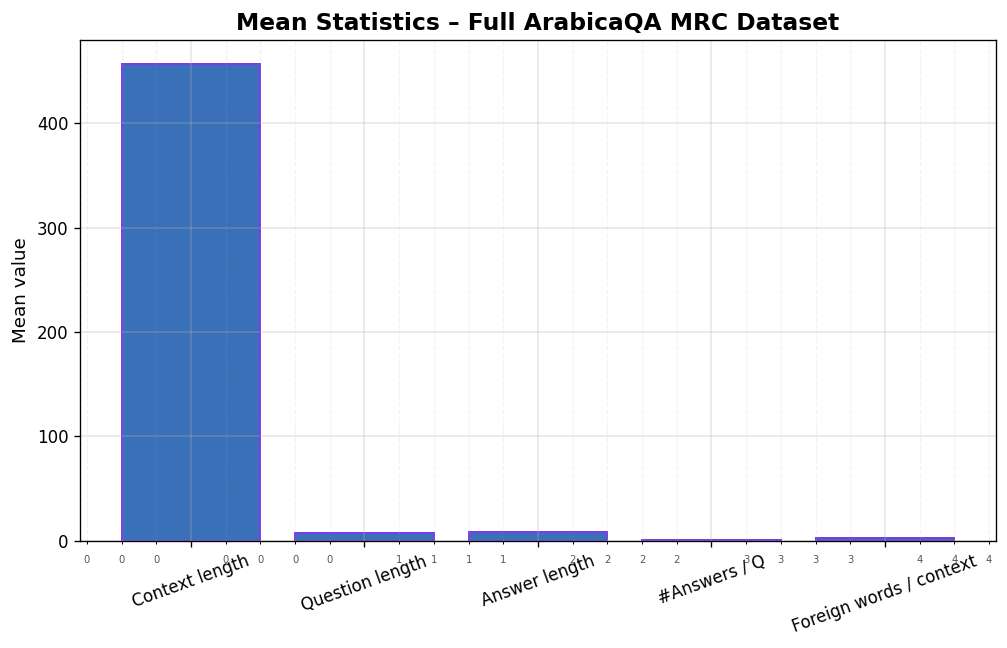

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_context_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_context_length.pdf


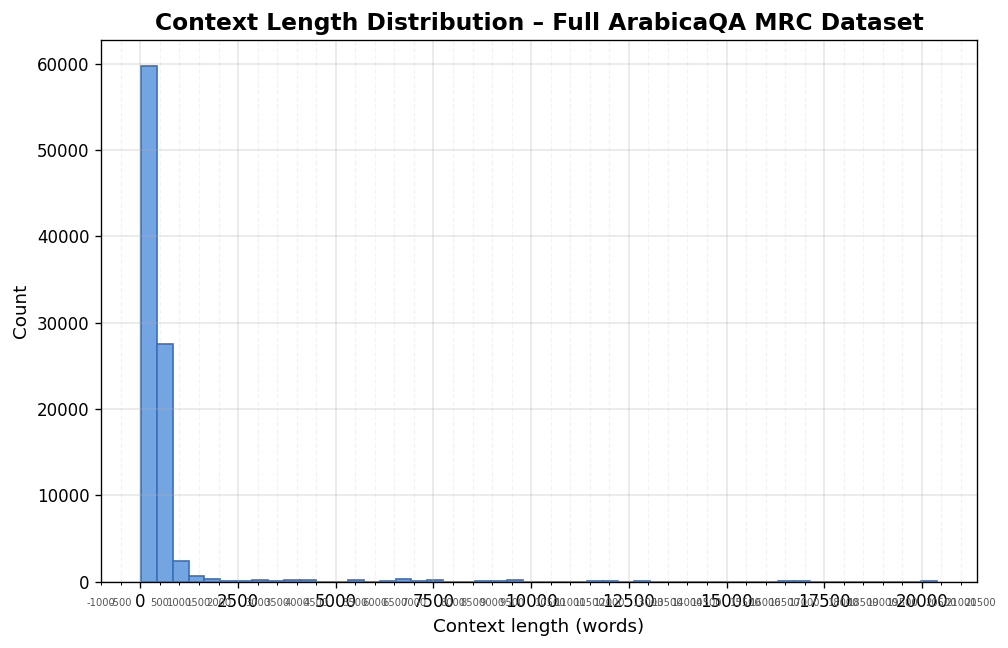

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_question_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_question_length.pdf


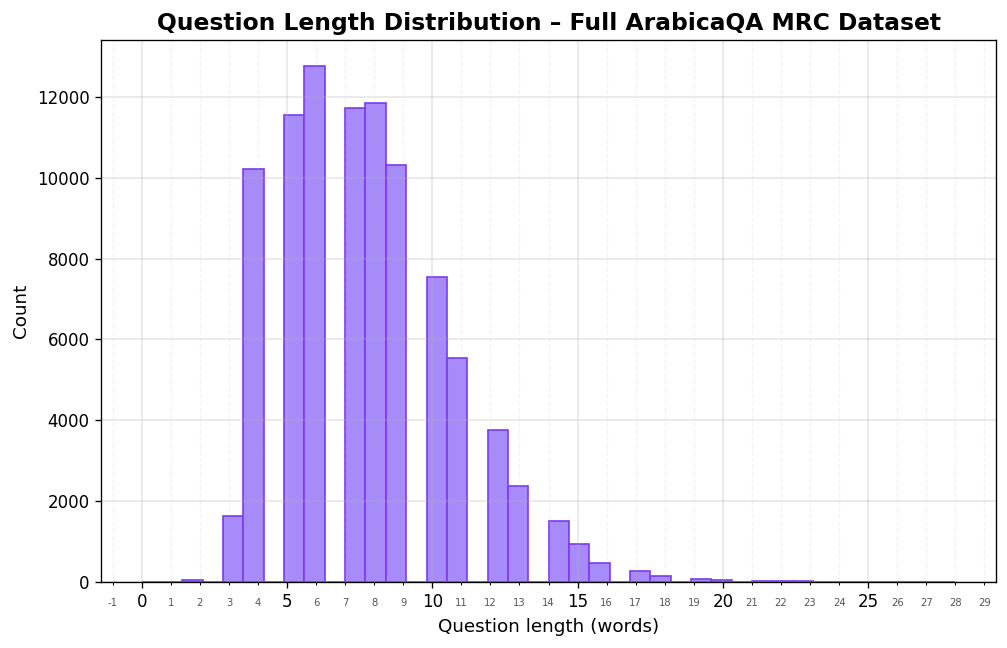

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_answer_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_answer_length.pdf


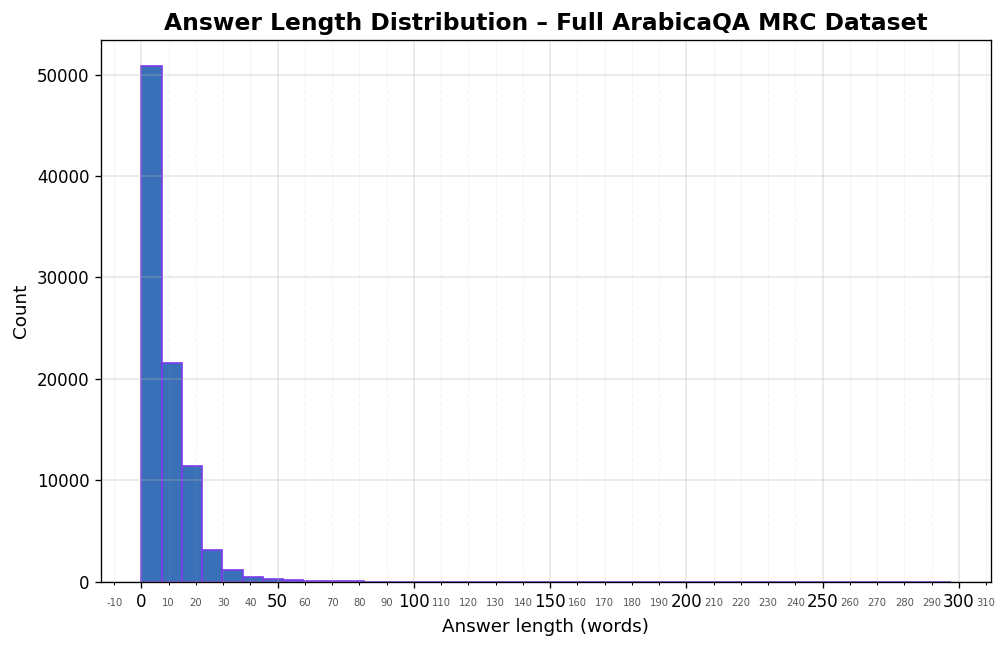

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_foreign_words.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_foreign_words.pdf


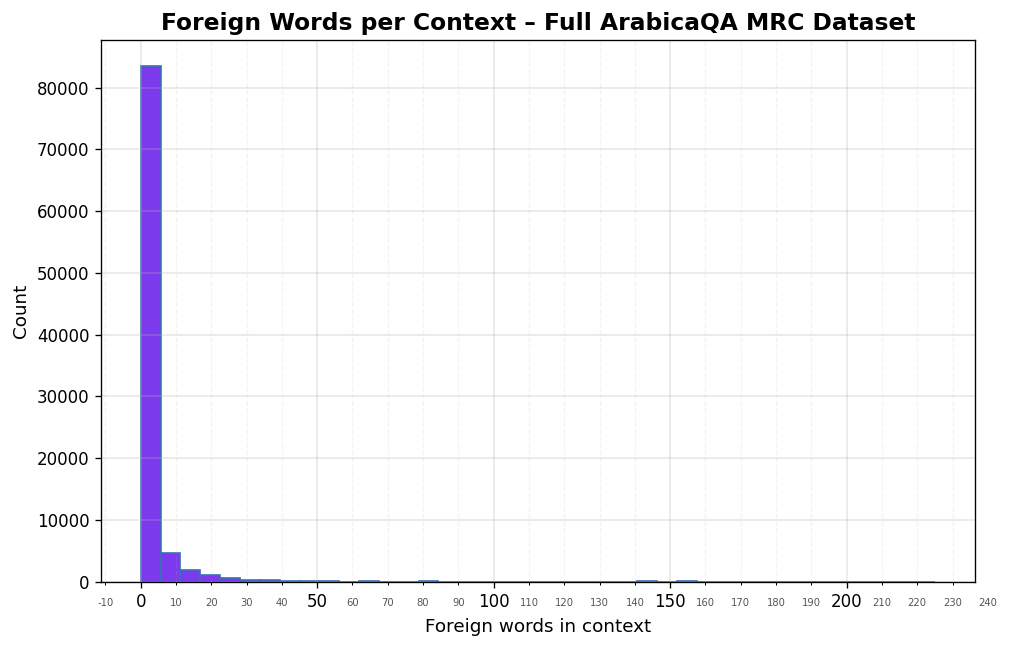

In [7]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_full")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# THEME
# ======================
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 120

def apply_style_with_minor_ticks(ax):
    """Apply theme + grid + minor ticks labels"""
    ax.grid(which="major", alpha=0.3, linewidth=1)
    ax.grid(which="minor", alpha=0.15, linestyle="--")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    minor_ticks = ax.xaxis.get_minorticklocs()
    for tick in minor_ticks:
        ax.text(
            tick,
            -0.045,
            f"{int(tick)}",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color="#555",
            ha="center"
        )

    plt.tight_layout()

def save_fig(name_base: str):
    """Save current figure as PNG + PDF."""
    png_path = os.path.join(FIG_DIR, f"{name_base}.png")
    pdf_path = os.path.join(FIG_DIR, f"{name_base}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("Saved →", png_path)
    print("Saved →", pdf_path)


# ======================================================
# 3) Bar plot of the means
# ======================================================
labels = [
    "Context length",
    "Question length",
    "Answer length",
    "#Answers / Q",
    "Foreign words / context",
]

values = [
    mean_context_len,
    mean_question_len,
    mean_answer_len,
    mean_n_answers,
    mean_foreign_per_context,
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(labels, values, color=PRIMARY, edgecolor=ACCENT2, linewidth=1.2)
ax.set_ylabel("Mean value")
ax.set_title("Mean Statistics – Full ArabicaQA MRC Dataset", fontsize=14)
ax.tick_params(axis="x", rotation=20)
apply_style_with_minor_ticks(ax)

save_fig("full_means_bar")
plt.show()


# ======================================================
# 4) Histograms for FULL DATA
# ======================================================

# ========= Context length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["context_word_len"], bins=50, color=SECONDARY, edgecolor=PRIMARY)
ax.set_xlabel("Context length (words)")
ax.set_ylabel("Count")
ax.set_title("Context Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_context_length")
plt.show()


# ========= Question length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["question_word_len"], bins=40, color=ACCENT1, edgecolor=ACCENT2)
ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Question Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_question_length")
plt.show()


# ========= Answer length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(all_answer_lengths, bins=40, color=PRIMARY, edgecolor=ACCENT2)
ax.set_xlabel("Answer length (words)")
ax.set_ylabel("Count")
ax.set_title("Answer Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_answer_length")
plt.show()


# ========= Foreign words per context =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["context_foreign_word_count"], bins=40, color=ACCENT2, edgecolor=PRIMARY)
ax.set_xlabel("Foreign words in context")
ax.set_ylabel("Count")
ax.set_title("Foreign Words per Context – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_foreign_words")
plt.show()


In [8]:
import pandas as pd
import json

# ========== 1) Read dataset ==========
df = pd.read_csv("arabicaqa_rag_results/dataset/df_all_mrc.csv")

# ========== 2) Decode list-like columns stored as JSON strings ==========
list_columns = ["answers"]  

for col in list_columns:
    df[col] = df[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

# ========== 3) Split dataset into answerable / unanswerable ==========
df_answerable = df[df["is_impossible"] == False]
df_unanswerable = df[df["is_impossible"] == True]

# ========== 4) Sample 500 from each ==========
sample_answerable = df_answerable.sample(500, random_state=42)
sample_unanswerable = df_unanswerable.sample(500, random_state=42)

# ========== 5) Combine into final sample ==========
df_sample = pd.concat([sample_answerable, sample_unanswerable], ignore_index=True)

print("Sample shape:", df_sample.shape)
df_sample.head()


Sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [9]:
import pandas as pd
import json

# ======================================================
# 1) Load the sample
# ======================================================

df_sample = df_sample.copy() 


# ======================================================
# 2) Helper: safe parsing for list-columns (answers)
# ======================================================

def safe_parse_list(x):
    """Return a clean Python list, fixing formatting problems."""
    
    if isinstance(x, list):
        return x
    
    if pd.isna(x):
        return []
    
    s = str(x).strip()
    if s == "":
        return []

    # Try JSON as-is
    try:
        return json.loads(s)
    except:
        pass
    
    # Try JSON with single-quotes replaced
    try:
        s2 = s.replace("'", '"')
        return json.loads(s2)
    except:
        pass
    
    # Fallback: return as single-item list
    return [s]


# ======================================================
# 3) Fix list-columns (answers)
# ======================================================

list_columns = ["answers"]

for col in list_columns:
    df_sample[col] = df_sample[col].apply(safe_parse_list)


# ======================================================
# 4) Clean other text columns: strip whitespace, ensure strings
# ======================================================

text_columns = ["question", "context"]

for col in text_columns:
    df_sample[col] = df_sample[col].fillna("").astype(str).str.strip()


# ======================================================
# 5) Optional safety checks (remove broken rows)
# ======================================================

# Remove empty context/question rows (rare but safe)
df_sample = df_sample[df_sample["question"] != ""]
df_sample = df_sample[df_sample["context"] != ""]

# Ensure is_impossible is boolean
df_sample["is_impossible"] = df_sample["is_impossible"].astype(bool)


# ======================================================
# 6) Save cleaned sample
# ======================================================

output_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"

# Convert lists into JSON before saving
df_to_save = df_sample.copy()
for col in list_columns:
    df_to_save[col] = df_to_save[col].apply(lambda x: json.dumps(x, ensure_ascii=False))

df_to_save.to_csv(output_path, index=False, encoding="utf-8-sig")

print("✨ Sample cleaned and saved to:", output_path)
print("Final shape:", df_sample.shape)


✨ Sample cleaned and saved to: arabicaqa_rag_results/dataset/df_sample_1000.csv
Final shape: (1000, 7)


In [10]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [11]:
import numpy as np
import re

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).split())

latin_pattern = re.compile(r"[A-Za-z]")

def foreign_word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    tokens = str(text).split()
    return sum(1 for t in tokens if latin_pattern.search(t))


df_sample_loaded["context_word_len"] = df_sample_loaded["context"].apply(word_count)
df_sample_loaded["question_word_len"] = df_sample_loaded["question"].apply(word_count)

df_sample_loaded["n_answers"] = df_sample_loaded["answers"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# answer lengths (global)
all_sample_answer_lengths = []
for ans_list in df_sample_loaded["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_sample_answer_lengths.append(word_count(a))

mean_context_len_s = df_sample_loaded["context_word_len"].mean()
mean_question_len_s = df_sample_loaded["question_word_len"].mean()
mean_n_answers_s = df_sample_loaded["n_answers"].mean()
mean_answer_len_s = np.mean(all_sample_answer_lengths) if all_sample_answer_lengths else 0
df_sample_loaded["foreign_words"] = df_sample_loaded["context"].apply(foreign_word_count)
mean_foreign_s = df_sample_loaded["foreign_words"].mean()

print("📊 Sample stats:")
print(f"- Mean context length (words):        {mean_context_len_s:.2f}")
print(f"- Mean question length (words):       {mean_question_len_s:.2f}")
print(f"- Mean #answers per question:         {mean_n_answers_s:.2f}")
print(f"- Mean answer length (words, global): {mean_answer_len_s:.2f}")
print(f"- Mean foreign words per context:     {mean_foreign_s:.2f}")


📊 Sample stats:
- Mean context length (words):        372.58
- Mean question length (words):       8.24
- Mean #answers per question:         0.50
- Mean answer length (words, global): 8.47
- Mean foreign words per context:     1.90


In [12]:
print("df_sample_loaded rows:", len(df_sample_loaded))
print("context_word_len non-null:", df_sample_loaded["context_word_len"].notna().sum())
print("unique context_word_len:", df_sample_loaded["context_word_len"].nunique(dropna=True))
print(df_sample_loaded["context_word_len"].describe())


df_sample_loaded rows: 1000
context_word_len non-null: 1000
unique context_word_len: 484
count    1000.000000
mean      372.585000
std       588.171091
min        12.000000
25%        89.000000
50%       296.500000
75%       500.000000
max      9463.000000
Name: context_word_len, dtype: float64


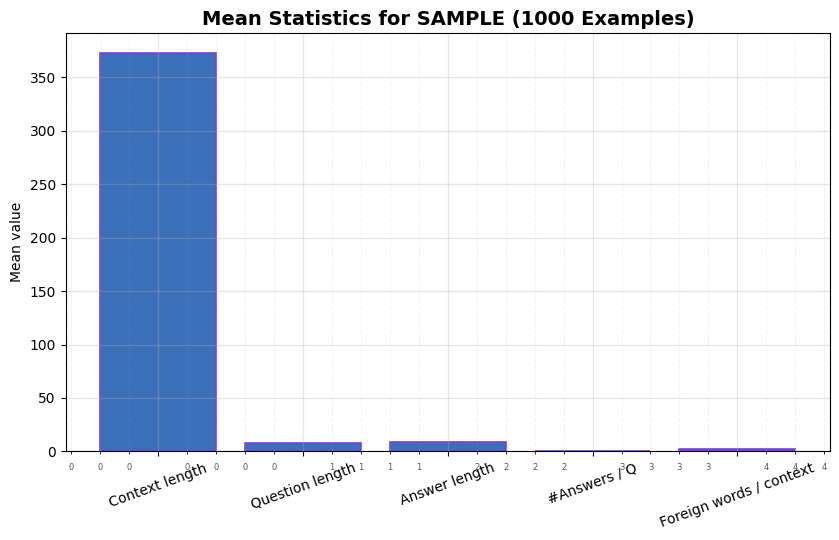

Saved → arabicaqa_rag_results/ragas_full\figures\mean_statistics_sample.png
Saved → arabicaqa_rag_results/ragas_full\figures\mean_statistics_sample.pdf


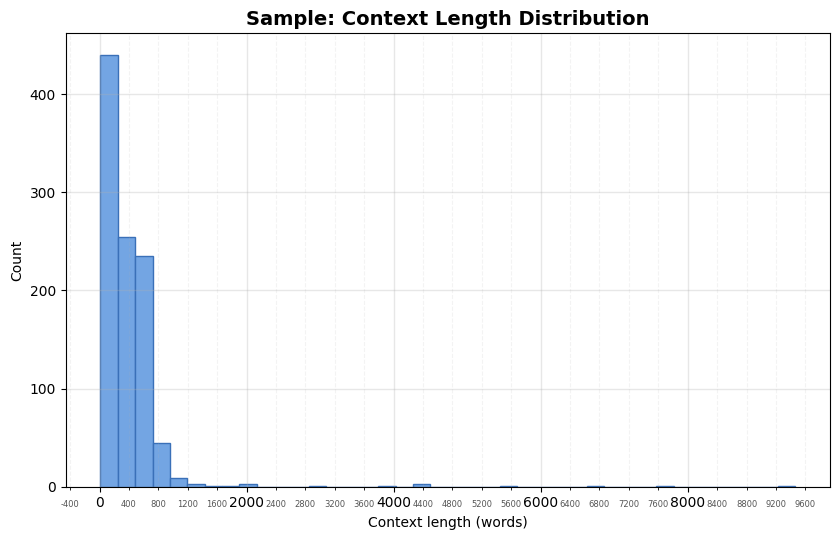

Saved → arabicaqa_rag_results/ragas_full\figures\hist_context_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_context_length.pdf


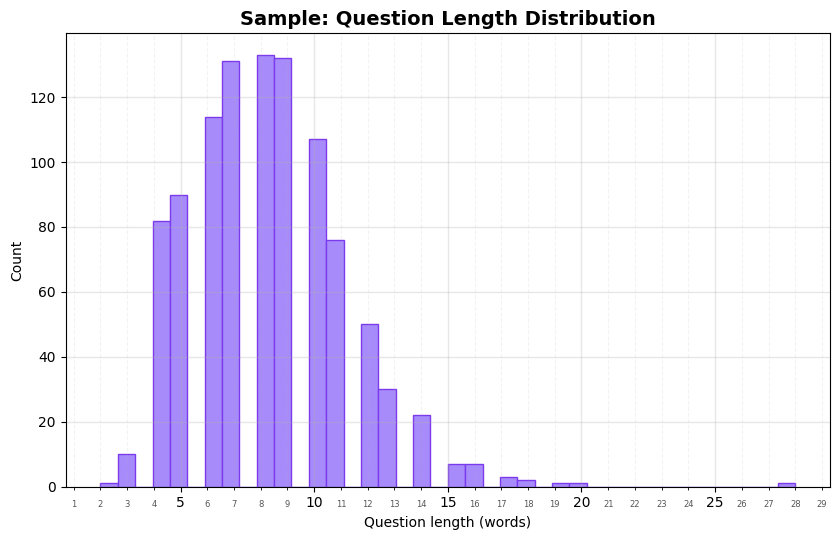

Saved → arabicaqa_rag_results/ragas_full\figures\hist_question_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_question_length.pdf


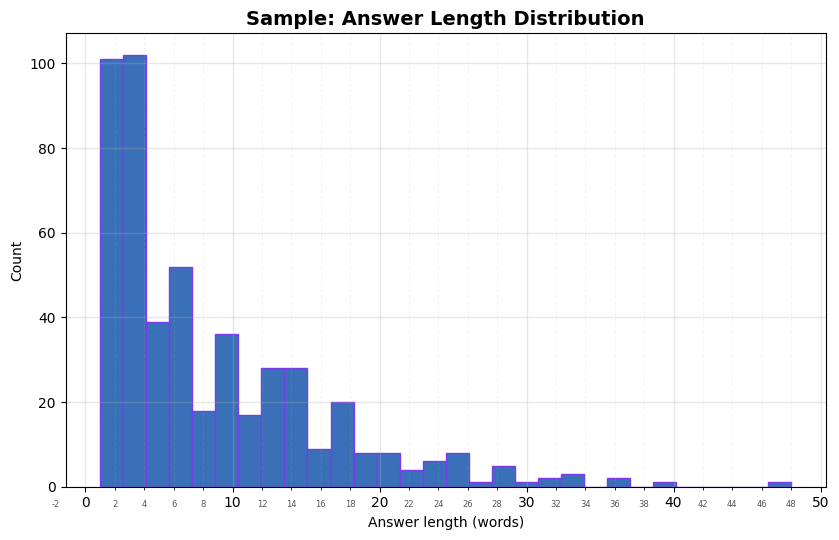

Saved → arabicaqa_rag_results/ragas_full\figures\hist_answer_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_answer_length.pdf


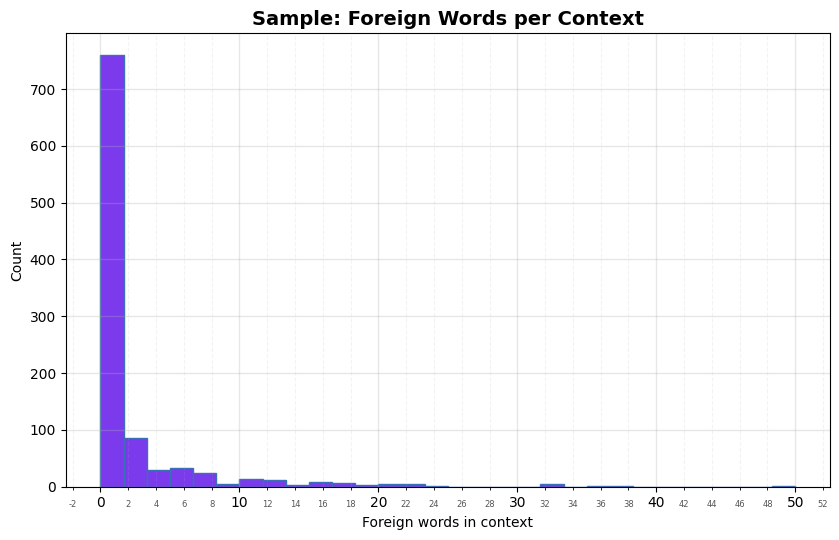

Saved → arabicaqa_rag_results/ragas_full\figures\hist_foreign_words.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_foreign_words.pdf


In [13]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# THEME
# ======================
plt.style.use("default")

PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple


def apply_style_with_minor_ticks(ax):
    """Apply theme + grid + minor ticks with small labels"""
    ax.grid(which="major", alpha=0.3, linewidth=1)
    ax.grid(which="minor", alpha=0.15, linestyle="--")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    minor_ticks = ax.xaxis.get_minorticklocs()
    for tick in minor_ticks:
        ax.text(
            tick,
            -0.045,
            f"{int(tick)}",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color="#555555",
            ha="center"
        )

    plt.tight_layout()


# =====================================================
# 1) BAR CHART — MEAN STATISTICS
# =====================================================
labels = [
    "Context length",
    "Question length",
    "Answer length",
    "#Answers / Q",
    "Foreign words / context",
]

values = [
    mean_context_len_s,
    mean_question_len_s,
    mean_answer_len_s,
    mean_n_answers_s,
    mean_foreign_s,
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(labels, values, color=PRIMARY, edgecolor=ACCENT2, linewidth=1.2)
ax.set_ylabel("Mean value")
ax.set_title("Mean Statistics for SAMPLE (1000 Examples)", fontsize=14, weight="bold")
ax.tick_params(axis="x", rotation=20)

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "mean_statistics_sample.png")
pdf = os.path.join(FIG_DIR, "mean_statistics_sample.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 2) HISTOGRAM — CONTEXT LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["context_word_len"], bins=40,
        color=SECONDARY, edgecolor=PRIMARY)

ax.set_xlabel("Context length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Context Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_context_length.png")
pdf = os.path.join(FIG_DIR, "hist_context_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 3) HISTOGRAM — QUESTION LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["question_word_len"], bins=40,
        color=ACCENT1, edgecolor=ACCENT2)

ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Question Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_question_length.png")
pdf = os.path.join(FIG_DIR, "hist_question_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 4) HISTOGRAM — ANSWER LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(all_sample_answer_lengths, bins=30,
        color=PRIMARY, edgecolor=ACCENT2)

ax.set_xlabel("Answer length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Answer Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_answer_length.png")
pdf = os.path.join(FIG_DIR, "hist_answer_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 5) HISTOGRAM — FOREIGN WORDS PER CONTEXT
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["foreign_words"], bins=30,
        color=ACCENT2, edgecolor=PRIMARY)

ax.set_xlabel("Foreign words in context")
ax.set_ylabel("Count")
ax.set_title("Sample: Foreign Words per Context", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_foreign_words.png")
pdf = os.path.join(FIG_DIR, "hist_foreign_words.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


In [14]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [15]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
from tqdm import tqdm
from collections import Counter

model_id = "CAMeL-Lab/bert-base-arabic-camelbert-msa-ner"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForTokenClassification.from_pretrained(model_id)

ner = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

def get_entity_counts(texts, max_tokens=512):
    entity_counter = Counter()
    for t in tqdm(texts):
        if not isinstance(t, str) or not t.strip():
            continue

        enc = tokenizer(
            t,
            truncation=True,
            max_length=max_tokens,
            return_tensors=None
        )
       
        input_ids = enc["input_ids"]
       
        if isinstance(input_ids[0], int):
            truncated_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        else:
            truncated_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)

        ents = ner(truncated_text)
        for e in ents:
            entity_counter[e["entity_group"]] += 1

    return entity_counter


# ==============================
# SAMPLE entities (ACTIVE)
# ==============================
sample_contexts = df_sample_loaded["context"].dropna().tolist()

sample_entity_counts = get_entity_counts(sample_contexts)

print("\n=== SAMPLE NER STATISTICS ===")
for k, v in sample_entity_counts.items():
    print(f"{k}: {v}")

df_ner = pd.DataFrame({
    "entity_type": list(sample_entity_counts.keys()),
    "sample": list(sample_entity_counts.values()),
})
df_ner.head()


c:\Users\Zohoor Almalki\Projects\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Zohoor Almalki\Projects\NLP\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Zohoor Almalki\.cache\huggingface\hub\models--CAMeL-Lab--bert-base-arabic-camelbert-msa-ner. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python 


=== SAMPLE NER STATISTICS ===
ORG: 2058
LOC: 11581
PERS: 6686
MISC: 3737


,entity_type,sample
0,ORG,2058
1,LOC,11581
2,PERS,6686
3,MISC,3737


In [16]:
import pandas as pd

ner_results_path = "arabicaqa_rag_results/dataset/sample_ner_counts.csv"

df_ner_loaded = pd.read_csv(ner_results_path)

print("✨ Loaded NER results:")
print(df_ner_loaded.head())


✨ Loaded NER results:
  entity_type  sample
0         ORG    2058
1         LOC   11581
2        PERS    6686
3        MISC    3737


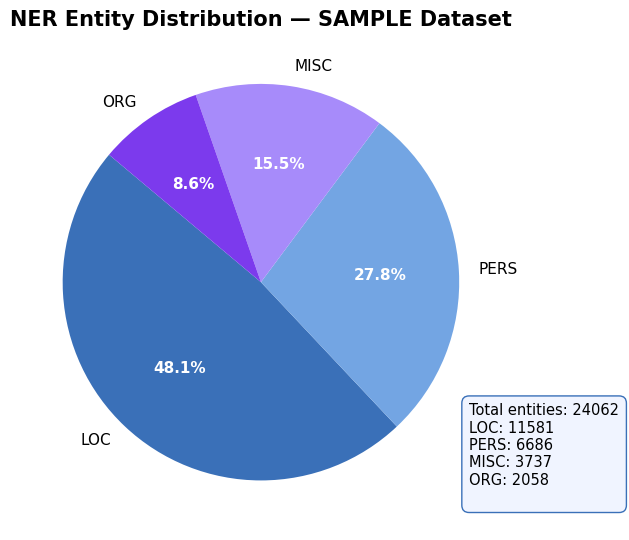

Saved → arabicaqa_rag_results/ragas_full\figures\ner_entity_distribution_pie.png
Saved → arabicaqa_rag_results/ragas_full\figures\ner_entity_distribution_pie.pdf


In [17]:
import os
import matplotlib.pyplot as plt

# ====== Theme colors ======
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

colors = [PRIMARY, SECONDARY, ACCENT1, ACCENT2, "#4FB6A0", "#F2A93B", "#D96459"]

# ======================
# PATH
# ======================
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# PREPARE DATA
# ======================
df_plot = df_ner_loaded.sort_values("sample", ascending=False)

labels = df_plot["entity_type"].astype(str).tolist()
sizes  = df_plot["sample"].astype(float).tolist()

total_entities = int(sum(sizes))

# ======================
# PIE CHART
# ======================
fig, ax = plt.subplots(figsize=(6.5, 5.5))

patches, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors[:len(labels)],
    startangle=140,
    textprops={"fontsize": 11}
)

# improve label style on wedges
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax.set_title("NER Entity Distribution — SAMPLE Dataset", fontsize=15, weight="bold")

# ========= Inset Box ==========
box_text = f"Total entities: {total_entities}\n"
for ent, count in zip(labels, sizes):
    box_text += f"{ent}: {int(count)}\n"

props = dict(boxstyle="round,pad=0.5", facecolor="#F0F4FF", edgecolor=PRIMARY)

ax.text(
    0.92, 0.05,                 # box position inside axes
    box_text,
    transform=ax.transAxes,
    fontsize=10.5,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=props
)

plt.tight_layout()

# ======================
# SAVE
# ======================
png_path = os.path.join(FIG_DIR, "ner_entity_distribution_pie.png")
pdf_path = os.path.join(FIG_DIR, "ner_entity_distribution_pie.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved → {png_path}")
print(f"Saved → {pdf_path}")


# **RAG Pipeline**

In [1]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.llms import Ollama
from langchain_classic.chains import RetrievalQA


print("✅ all imports OK (new LangChain)")


c:\Users\Zohoor Almalki\Projects\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ all imports OK (new LangChain)


In [3]:
# ========= 1) corpus with document_id =========
unique_contexts = (
    df_sample_loaded[["document_id", "context"]]
    .dropna(subset=["context"])
    .drop_duplicates(subset=["document_id"])
    .reset_index(drop=True)
)

len(unique_contexts), unique_contexts.iloc[0]["context"][:200]


(919,
 'توب غولف هي شركة ترفيهية رياضية عالمية مقرها في دالاس، تكساس ولها مواقع في الولايات المتحدة والمملكة المتحدة وأستراليا والمكسيك ودبي. تم الاستحواذ على الشركة من قبل Callaway Golf المتداولة علنًا في ما')

In [4]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

unique_contexts = (
    df_sample_loaded[["document_id", "context"]]
    .dropna(subset=["context"])
    .drop_duplicates(subset=["document_id"])
    .reset_index(drop=True)
)

docs = []
for _, row in unique_contexts.iterrows():
    doc_id = int(row["document_id"])
    text = row["context"]

    chunks = text_splitter.split_text(text)
    for i, chunk in enumerate(chunks):
        docs.append(
            Document(
                page_content=chunk,
                metadata={"document_id": doc_id, "chunk_id": i}
            )
        )

print("Example metadata:", docs[0].metadata)
print(f"✅ Created {len(docs)} chunks")


Example metadata: {'document_id': 1732461, 'chunk_id': 0}
✅ Created 6026 chunks


In [5]:
# ========= 3) Vector DB (Chroma + HF embeddings) =========
from langchain_community.vectorstores import Chroma
from tqdm.auto import tqdm  

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

vectordb = Chroma(
    collection_name="arabicaqa_mrc_v1_docid",   
    embedding_function=embeddings,
    persist_directory="chroma_arabicaqa_docid" 
)

BATCH_SIZE = 5000
for i in tqdm(range(0, len(docs), BATCH_SIZE)):
    batch_docs = docs[i : i + BATCH_SIZE]
    vectordb.add_documents(batch_docs)

vectordb.persist()

retriever = vectordb.as_retriever(search_kwargs={"k": 5})


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_2752\789031023.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_2752\789031023.py:9: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(
100%|██████████| 2/2 [04:05<00:00, 122.73s/it]
C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_2752\789031023.py:20

In [6]:
hits = retriever.invoke(df_sample_loaded["question"].iloc[0])
print(hits[0].metadata)


{'chunk_id': 4, 'document_id': 1732461}


## **Answers Generation**

In [ ]:
import os
import json
import time
import ast
import math
import pandas as pd
from tqdm import tqdm

from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import RetrievalQA

# ============================================================
# 0) Configuration
# ============================================================
TEST_MODE = False
N_ANSWERABLE_TEST = 1
N_UNANSWERABLE_TEST = 1

SKIP_IF_MODEL_FILE_EXISTS = False
MERGE_AT_END = True

SAMPLE_PATH = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
OUTPUT_DIR = "arabicaqa_rag_results/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FINAL_OUTPUT_CSV = os.path.join(OUTPUT_DIR, "comparison_llama_mistral_qwen_1000.csv")
FINAL_OUTPUT_JSON = os.path.join(OUTPUT_DIR, "comparison_llama_mistral_qwen_1000.json")

# ============================================================
# Models: run one model fully, then the next
# ============================================================
MODELS = {
    "qwen": "qwen2.5:7b-instruct",
    "llama": "llama3:8b",
    "mistral": "mistral:7b-instruct",
}

# ============================================================
# 1) Load the fixed evaluation subset
# ============================================================
df_sample = pd.read_csv(SAMPLE_PATH)

print("=" * 90)
print("SEQUENTIAL MULTI-MODEL RAG GENERATION")
print("=" * 90)
print("Loaded sample:", SAMPLE_PATH)
print("Original shape:", df_sample.shape)

# ============================================================
# 2) Optional Smoke Test
# is_impossible == False => answerable
# is_impossible == True  => unanswerable
# ============================================================
if TEST_MODE:
    df_ans = df_sample[df_sample["is_impossible"] == False].head(N_ANSWERABLE_TEST)
    df_un = df_sample[df_sample["is_impossible"] == True].head(N_UNANSWERABLE_TEST)
    df_sample = pd.concat([df_ans, df_un], ignore_index=True)

    print("\nTEST MODE ENABLED")
    print("Smoke test shape:", df_sample.shape)
    print(df_sample["is_impossible"].value_counts())
else:
    print("\nFULL RUN MODE")
    print("Running all rows:", df_sample.shape)

# ============================================================
# 3) Basic validation and parsing
# ============================================================
required_cols = ["is_impossible", "question", "answers"]
missing = [c for c in required_cols if c not in df_sample.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

def parse_answers(x):
    if x is None:
        return []
    if isinstance(x, float) and math.isnan(x):
        return []
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
        except Exception:
            pass
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            return [str(parsed).strip()] if str(parsed).strip() else []
        except Exception:
            return [s]
    return []

df_sample["answers"] = df_sample["answers"].apply(parse_answers)
df_sample["is_impossible"] = df_sample["is_impossible"].astype(bool)
df_sample["is_answerable"] = ~df_sample["is_impossible"]

print("\nSample ready:", df_sample.shape)

# ============================================================
# 4) Shared prompt
# ============================================================
template = """
أجب عن السؤال التالي باللغة العربية الفصحى فقط،
وبأقصر وأدق إجابة ممكنة.
لا تضف أي شرح أو مقدمة أو معلومات من خارج السياق.
إذا لم تكن الإجابة موجودة في السياق، اكتب فقط: "غير موجود في السياق."

السؤال: {question}

السياق:
{context}

الإجابة:
"""

prompt = PromptTemplate(
    template=template,
    input_variables=["question", "context"]
)

# ============================================================
# 5) Helper: run one model fully
# ============================================================
def run_single_model(model_key, ollama_model_name, df_eval):
    output_csv = os.path.join(OUTPUT_DIR, f"predictions_{model_key}_1000.csv")
    output_json = os.path.join(OUTPUT_DIR, f"predictions_{model_key}_1000.json")

    if SKIP_IF_MODEL_FILE_EXISTS and os.path.exists(output_csv):
        print("\n" + "=" * 90)
        print(f"SKIPPING {model_key}: existing file found")
        print(output_csv)
        print("=" * 90)
        return pd.read_csv(output_csv, encoding="utf-8-sig")

    print("\n" + "=" * 90)
    print(f"RUNNING MODEL: {model_key} -> {ollama_model_name}")
    print("=" * 90)

    llm = Ollama(
        model=ollama_model_name,
        temperature=0.0,
        num_predict=64,
    )

    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        retriever=retriever,  # assumes retriever exists
        chain_type="stuff",
        chain_type_kwargs={"prompt": prompt},
        return_source_documents=True,
    )

    answer_col = f"predicted_answer_{model_key}"
    latency_col = f"latency_sec_{model_key}"
    error_col = f"error_{model_key}"

    results = []

    for idx, row in tqdm(
        df_eval.iterrows(),
        total=len(df_eval),
        desc=f"Generating with {model_key}"
    ):
        question = row["question"]

        record = {
            "row_idx": idx,
            "split": row.get("split", ""),
            "document_id": row.get("document_id", ""),
            "question_id": row.get("question_id", ""),
            "question": question,
            "context": row.get("context", ""),
            "correct_answers": row["answers"],
            "is_impossible": bool(row.get("is_impossible", False)),
            "is_answerable": not bool(row.get("is_impossible", False)),

            "retrieved_contexts": [],
            "retrieved_doc_ids": [],
            "retrieved_chunk_ids": [],

            answer_col: "ERROR",
            latency_col: None,
            error_col: "",
        }

        start_time = time.perf_counter()

        try:
            output = qa_chain.invoke({"query": question})

            source_docs = output.get("source_documents", [])

            record["retrieved_contexts"] = [
                d.page_content for d in source_docs
            ]

            record["retrieved_doc_ids"] = [
                d.metadata.get("document_id", None)
                for d in source_docs
            ]

            record["retrieved_chunk_ids"] = [
                d.metadata.get("chunk_id", None)
                for d in source_docs
            ]

            if isinstance(output, dict) and "result" in output:
                record[answer_col] = str(output["result"]).strip()
            else:
                record[answer_col] = str(output).strip()

        except Exception as e:
            record[error_col] = str(e)
            print(f"\n{model_key} error on question {idx}: {e}")

        end_time = time.perf_counter()
        record[latency_col] = end_time - start_time

        results.append(record)

        time.sleep(0.15)

    df_model = pd.DataFrame(results)

    df_model.to_csv(output_csv, index=False, encoding="utf-8-sig")
    df_model.to_json(output_json, orient="records", lines=True, force_ascii=False)

    print("\nDONE:", model_key)
    print("Saved CSV :", output_csv)
    print("Saved JSON:", output_json)
    print("Rows:", len(df_model))

    n_errors = int((df_model[answer_col] == "ERROR").sum())
    mean_latency = df_model[latency_col].mean()
    median_latency = df_model[latency_col].median()
    p95_latency = df_model[latency_col].quantile(0.95)

    print("Errors:", n_errors)
    print(f"Mean latency:   {mean_latency:.3f} sec/query")
    print(f"Median latency: {median_latency:.3f} sec/query")
    print(f"P95 latency:    {p95_latency:.3f} sec/query")

    return df_model

# ============================================================
# 6) Run models sequentially
# ============================================================
model_dfs = {}

for model_key, ollama_model_name in MODELS.items():
    df_model = run_single_model(model_key, ollama_model_name, df_sample)
    model_dfs[model_key] = df_model

print("\n" + "=" * 90)
print("ALL REQUESTED MODEL RUNS FINISHED OR SKIPPED")
print("=" * 90)

# ============================================================
# 7) Merge model outputs
# ============================================================
if MERGE_AT_END:
    print("\nMerging model files...")

    model_files = {
        model_key: os.path.join(OUTPUT_DIR, f"predictions_{model_key}_1000.csv")
        for model_key in MODELS.keys()
    }

    existing_model_files = {
        model_key: path
        for model_key, path in model_files.items()
        if os.path.exists(path)
    }

    if not existing_model_files:
        raise FileNotFoundError("No model prediction files found to merge.")

    print("Files found:")
    for model_key, path in existing_model_files.items():
        print(f" - {model_key}: {path}")

    dfs = {}
    for model_key, path in existing_model_files.items():
        df = pd.read_csv(path, encoding="utf-8-sig")
        dfs[model_key] = df
        print(model_key, df.shape)

    # Prefer llama as base if available; otherwise first available model.
    base_model = "llama" if "llama" in dfs else list(dfs.keys())[0]
    print("\nBase model for metadata:", base_model)

    base_cols = [
        "row_idx",
        "split",
        "document_id",
        "question_id",
        "question",
        "context",
        "correct_answers",
        "is_impossible",
        "is_answerable",
        "retrieved_contexts",
        "retrieved_doc_ids",
        "retrieved_chunk_ids",
    ]

    available_base_cols = [c for c in base_cols if c in dfs[base_model].columns]

    df_merged = dfs[base_model][available_base_cols].copy()

    for model_key, df_model in dfs.items():
        model_cols = [
            "row_idx",
            f"predicted_answer_{model_key}",
            f"latency_sec_{model_key}",
            f"error_{model_key}",
        ]

        missing_model_cols = [c for c in model_cols if c not in df_model.columns]
        if missing_model_cols:
            raise KeyError(f"Missing columns in {model_key} file: {missing_model_cols}")

        df_merged = df_merged.merge(
            df_model[model_cols],
            on="row_idx",
            how="left",
            validate="one_to_one",
        )

    df_merged = df_merged.sort_values("row_idx").reset_index(drop=True)

    df_merged.to_csv(FINAL_OUTPUT_CSV, index=False, encoding="utf-8-sig")
    df_merged.to_json(FINAL_OUTPUT_JSON, orient="records", lines=True, force_ascii=False)

    print("\nMerged results saved:")
    print("CSV :", FINAL_OUTPUT_CSV)
    print("JSON:", FINAL_OUTPUT_JSON)
    print("Shape:", df_merged.shape)

    print("\nMerged summary:")
    for model_key in existing_model_files.keys():
        answer_col = f"predicted_answer_{model_key}"
        latency_col = f"latency_sec_{model_key}"

        n_errors = int((df_merged[answer_col] == "ERROR").sum())
        mean_latency = df_merged[latency_col].mean()
        median_latency = df_merged[latency_col].median()
        p95_latency = df_merged[latency_col].quantile(0.95)

        print(f"\nModel: {model_key}")
        print(f"Errors:         {n_errors}")
        print(f"Mean latency:   {mean_latency:.3f} sec/query")
        print(f"Median latency: {median_latency:.3f} sec/query")
        print(f"P95 latency:    {p95_latency:.3f} sec/query")

    print("\nAnswerability counts:")
    print(df_merged["is_impossible"].value_counts())

    print("\nRetrieved evidence check:")
    print("retrieved_contexts missing:", df_merged["retrieved_contexts"].isna().sum())
    print("retrieved_doc_ids missing:", df_merged["retrieved_doc_ids"].isna().sum())
    print("retrieved_chunk_ids missing:", df_merged["retrieved_chunk_ids"].isna().sum())

    display(df_merged.head())

SEQUENTIAL MULTI-MODEL RAG GENERATION
Loaded sample: arabicaqa_rag_results/dataset/df_sample_1000.csv
Original shape: (1000, 7)

FULL RUN MODE
Running all rows: (1000, 7)

Sample ready: (1000, 8)

SKIPPING qwen: existing file found
arabicaqa_rag_results/predictions\predictions_qwen_1000.csv

SKIPPING llama: existing file found
arabicaqa_rag_results/predictions\predictions_llama_1000.csv

SKIPPING mistral: existing file found
arabicaqa_rag_results/predictions\predictions_mistral_1000.csv

ALL REQUESTED MODEL RUNS FINISHED OR SKIPPED

Merging model files...
Files found:
 - qwen: arabicaqa_rag_results/predictions\predictions_qwen_1000.csv
 - llama: arabicaqa_rag_results/predictions\predictions_llama_1000.csv
 - mistral: arabicaqa_rag_results/predictions\predictions_mistral_1000.csv
qwen (2, 15)
llama (2, 15)
mistral (2, 15)

Base model for metadata: llama

Merged results saved:
CSV : arabicaqa_rag_results/predictions\comparison_llama_mistral_qwen_1000.csv
JSON: arabicaqa_rag_results/predi

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_qwen,latency_sec_qwen,error_qwen,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,['عام 2000'],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 4, 4, 4, 4]",غير موجود في السياق.,217.083988,NaN,غير موجود في السياق.,190.849487,NaN,لم يتم بناء الموقع الأول لشركة توب غولف حتى عا...,491.875089,NaN
1,1,train,1450918,967260,ما هي التحديات التي واجهها رؤوف دنكتاش خلال فت...,رؤوف دنكتاش (27 يناير 1924 - 13 يناير 2012) كا...,[],True,False,['في أواخر الـ 1960، تدهورت قدراته البدنية: بد...,...,"[8, 8, 8, 8, 8]",غير موجود في السياق.,177.043332,NaN,غير موجود في السياق.,169.233484,NaN,التحديات التي واجهها رؤوف دنكتاش خلال فترة رئا...,476.583162,NaN


In [8]:
# ============================================================
# 0) Paths + Load df_results
# ============================================================
import os
import pandas as pd

output_dir = "arabicaqa_rag_results/predictions"
df_results_name = "comparison_llama_mistral_qwen_1000.csv"
df_results_path = os.path.join(output_dir, df_results_name)

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)
df_results.head()

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral,predicted_answer_qwen,latency_sec_qwen,error_qwen
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,['عام 2000'],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 4, 4, 4, 4]",غير موجود في السياق.,190.849487,NaN,لم يتم بناء الموقع الأول لشركة توب غولف حتى عا...,491.875089,NaN,غير موجود في السياق.,217.083988,NaN
1,1,train,1450918,967260,ما هي التحديات التي واجهها رؤوف دنكتاش خلال فت...,رؤوف دنكتاش (27 يناير 1924 - 13 يناير 2012) كا...,[],True,False,['في أواخر الـ 1960، تدهورت قدراته البدنية: بد...,...,"[8, 8, 8, 8, 8]",غير موجود في السياق.,169.233484,NaN,التحديات التي واجهها رؤوف دنكتاش خلال فترة رئا...,476.583162,NaN,غير موجود في السياق.,177.043332,NaN


In [9]:
# ============================================================
# Data Integrity Check:
# Empty gold answers vs. is_impossible labels
# ============================================================

import os
import math
import pandas as pd

def is_empty_gold(x):
    if x is None:
        return True

    if isinstance(x, float) and math.isnan(x):
        return True

    if isinstance(x, (list, tuple)):
        cleaned = [str(t).strip() for t in x if str(t).strip()]
        return len(cleaned) == 0

    return str(x).strip() == ""

empty_mask = df_results["correct_answers"].apply(is_empty_gold)

# Make sure is_impossible is boolean
df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

empty_gold_count = int(empty_mask.sum())
empty_gold_pct = round(empty_mask.mean() * 100, 2)

empty_gold_but_answerable = df_results[
    empty_mask & (df_results["is_impossible"] == False)
].copy()

nonempty_gold_but_unanswerable = df_results[
    (~empty_mask) & (df_results["is_impossible"] == True)
].copy()

print("=" * 80)
print("DATA INTEGRITY CHECK: GOLD ANSWERS vs ANSWERABILITY")
print("=" * 80)
print(f"Total rows: {len(df_results):,}")
print(f"Empty gold count: {empty_gold_count:,}")
print(f"Empty gold %: {empty_gold_pct:.2f}%")
print("-" * 80)
print(
    "Empty gold but is_impossible=False count:",
    len(empty_gold_but_answerable)
)
print(
    "Non-empty gold but is_impossible=True count:",
    len(nonempty_gold_but_unanswerable)
)
print("=" * 80)

# Save diagnostics
diagnostics_dir = "arabicaqa_rag_results/diagnostics"
os.makedirs(diagnostics_dir, exist_ok=True)

summary = pd.DataFrame([
    {
        "total_rows": len(df_results),
        "empty_gold_count": empty_gold_count,
        "empty_gold_percent": empty_gold_pct,
        "empty_gold_but_answerable_count": len(empty_gold_but_answerable),
        "nonempty_gold_but_unanswerable_count": len(nonempty_gold_but_unanswerable),
    }
])

summary_path = os.path.join(diagnostics_dir, "gold_answer_integrity_summary.csv")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

if len(empty_gold_but_answerable) > 0:
    path1 = os.path.join(diagnostics_dir, "empty_gold_but_answerable_rows.csv")
    empty_gold_but_answerable.to_csv(path1, index=False, encoding="utf-8-sig")
    print("Saved problematic rows:", path1)

if len(nonempty_gold_but_unanswerable) > 0:
    path2 = os.path.join(diagnostics_dir, "nonempty_gold_but_unanswerable_rows.csv")
    nonempty_gold_but_unanswerable.to_csv(path2, index=False, encoding="utf-8-sig")
    print("Saved inconsistent rows:", path2)

print("Saved summary:", summary_path)

summary

DATA INTEGRITY CHECK: GOLD ANSWERS vs ANSWERABILITY
Total rows: 2
Empty gold count: 0
Empty gold %: 0.00%
--------------------------------------------------------------------------------
Empty gold but is_impossible=False count: 0
Non-empty gold but is_impossible=True count: 1
Saved inconsistent rows: arabicaqa_rag_results/diagnostics\nonempty_gold_but_unanswerable_rows.csv
Saved summary: arabicaqa_rag_results/diagnostics\gold_answer_integrity_summary.csv


,total_rows,empty_gold_count,empty_gold_percent,empty_gold_but_answerable_count,nonempty_gold_but_unanswerable_count
0,2,0,0.0,0,1


In [14]:
import os
import json
import math
import ast
import re
import pandas as pd
from datetime import datetime
from evaluate import load

# ============================================================
# 0) Paths + Load df_results
# ============================================================
output_dir = "arabicaqa_rag_results/predictions"

df_results_name = "comparison_llama_mistral_qwen_1000.csv"
df_results_path = os.path.join(output_dir, df_results_name)

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)

print("\n" + "=" * 80)
print(" CALCULATING OFFICIAL SCORES")
print("=" * 80)
print(f"Loaded df_results: {df_results_path}")
print(f"Rows: {len(df_results):,}")
print(f"Columns: {list(df_results.columns)}")

# ============================================================
# 1) Detect models dynamically
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if not model_keys:
    raise KeyError("No predicted_answer_* columns found in df_results.")

print("\nDetected models:")
for m in model_keys:
    print(f" - {m}")

required_cols = ["correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns in df_results: {missing}")

# ============================================================
# 2) Arabic normalization + No-answer detector
# ============================================================
def normalize_arabic_text(s: str) -> str:
    if s is None:
        return ""

    s = str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize common Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation
    s = re.sub(r"[.,!?؟،؛:\"'«»()\[\]{}]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

NO_ANSWER = "غير موجود في السياق"
NO_ANSWER_CANON = normalize_arabic_text(NO_ANSWER)

NO_ANSWER_PATTERNS = [
    r"غير موجود",
    r"غير متوفر",
    r"غير مذكور",
    r"ليس مذكور",
    r"لا (يوجد|توجد)",
    r"لا يذكر",
    r"لا تتوفر",
    r"لا يمكن (العثور|تحديد|الاجابه|الإجابة)",
    r"المعلومات غير متوفره",
    r"المعلومات غير متوفرة",
    r"لا يحتوي السياق",
]

def is_no_answer(text: str) -> bool:
    t = normalize_arabic_text(text)
    if not t:
        return False

    if t == NO_ANSWER_CANON:
        return True

    for pat in NO_ANSWER_PATTERNS:
        if re.search(pat, t):
            return True

    return False

# ============================================================
# 3) Parse correct_answers from CSV
# ============================================================
def parse_maybe_list(x):
    if x is None:
        return x

    if isinstance(x, float) and math.isnan(x):
        return x

    if isinstance(x, str):
        s = x.strip()

        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass

            try:
                return ast.literal_eval(s)
            except Exception:
                return x

        return x

    return x

def force_list(x):
    """
    Make correct_answers always a list.
    If empty or missing, map to [NO_ANSWER].
    """
    if x is None:
        return [NO_ANSWER]

    if isinstance(x, float) and math.isnan(x):
        return [NO_ANSWER]

    if isinstance(x, (list, tuple)):
        x = list(x)
        cleaned = []
        for item in x:
            if item is None:
                continue
            if isinstance(item, float) and math.isnan(item):
                continue
            item = str(item).strip()
            if item:
                cleaned.append(item)

        return cleaned if cleaned else [NO_ANSWER]

    s = str(x).strip()
    return [s] if s else [NO_ANSWER]

df_results["correct_answers"] = (
    df_results["correct_answers"]
    .apply(parse_maybe_list)
    .apply(force_list)
)

df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

# ============================================================
# 4) Load official metrics
# ============================================================
em_metric = load("exact_match")
em25_metric = load("exact_match", "exact_match_25")

def normalize_refs(refs):
    if refs is None:
        return [NO_ANSWER]

    if isinstance(refs, float) and math.isnan(refs):
        return [NO_ANSWER]

    if isinstance(refs, str):
        s = refs.strip()
        return [s] if s else [NO_ANSWER]

    if isinstance(refs, (list, tuple)):
        if len(refs) == 1 and isinstance(refs[0], (list, tuple)):
            refs = refs[0]

        cleaned = []
        for r in refs:
            if r is None:
                continue
            if isinstance(r, float) and math.isnan(r):
                continue
            r = str(r).strip()
            if r:
                cleaned.append(r)

        return cleaned if cleaned else [NO_ANSWER]

    s = str(refs).strip()
    return [s] if s else [NO_ANSWER]

def normalize_pred(pred):
    if pred is None:
        return ""

    if isinstance(pred, float) and math.isnan(pred):
        return ""

    return str(pred).strip()

def compute_scores(predictions, references_list):
    em_scores = []
    em25_scores = []

    for pred, refs in zip(predictions, references_list):
        pred = normalize_pred(pred)
        refs = normalize_refs(refs)

        best_em = max(
            em_metric.compute(
                predictions=[pred],
                references=[ref],
                ignore_case=True,
                ignore_punctuation=True
            )["exact_match"]
            for ref in refs
        )

        best_em25 = max(
            em25_metric.compute(
                predictions=[pred],
                references=[ref],
                ignore_case=True,
                ignore_punctuation=True
            )["exact_match"]
            for ref in refs
        )

        em_scores.append(best_em)
        em25_scores.append(best_em25)

    avg_em = round(sum(em_scores) / len(em_scores) * 100, 2) if em_scores else 0.0
    avg_em25 = round(sum(em25_scores) / len(em25_scores) * 100, 2) if em25_scores else 0.0

    return avg_em, avg_em25

def no_answer_stats(pred_series):
    flags = pred_series.fillna("").apply(is_no_answer)
    y = int(flags.sum())
    x = int(len(flags))
    acc = round((y / x) * 100, 2) if x else 0.0
    return y, x, acc

# ============================================================
# 5) Compute scores for all detected models
# ============================================================
ans_mask = df_results["is_impossible"] == False
un_mask = df_results["is_impossible"] == True

df_ans = df_results[ans_mask].copy()
df_un = df_results[un_mask].copy()

gold_answers = df_results["correct_answers"].tolist()

summary_rows = []
summary = {
    "date": datetime.now().isoformat(),
    "dataset": "ArabicaQA fixed 1,000-question sample",
    "df_results_path": df_results_path,
    "no_answer_label": NO_ANSWER,
    "counts": {
        "total": int(len(df_results)),
        "answerable": int(len(df_ans)),
        "unanswerable": int(len(df_un)),
    },
    "models": {}
}

for model_key in model_keys:
    pred_col = f"predicted_answer_{model_key}"
    latency_col = f"latency_sec_{model_key}"
    error_col = f"error_{model_key}"

    preds_all = df_results[pred_col].tolist()
    preds_ans = df_ans[pred_col].tolist()

    # Overall:
    # unanswerables are mapped to NO_ANSWER through correct_answers.
    em_overall, em25_overall = compute_scores(preds_all, gold_answers)

    # Answerable only
    em_ans, em25_ans = compute_scores(
        preds_ans,
        df_ans["correct_answers"].tolist()
    )

    # Unanswerable abstention
    noans_y, noans_x, noans_acc = no_answer_stats(df_un[pred_col])

    # Errors
    n_errors = int((df_results[pred_col].fillna("") == "ERROR").sum())

    # Latency, if available
    if latency_col in df_results.columns:
        latency_mean = round(float(df_results[latency_col].mean()), 4)
        latency_median = round(float(df_results[latency_col].median()), 4)
        latency_p95 = round(float(df_results[latency_col].quantile(0.95)), 4)
        latency_std = round(float(df_results[latency_col].std()), 4)
    else:
        latency_mean = None
        latency_median = None
        latency_p95 = None
        latency_std = None

    row = {
        "model": model_key,
        "overall_em": em_overall,
        "overall_em25": em25_overall,
        "answerable_em": em_ans,
        "answerable_em25": em25_ans,
        "unanswerable_no_answer_count": noans_y,
        "unanswerable_total": noans_x,
        "unanswerable_abstention_accuracy": noans_acc,
        "errors": n_errors,
        "latency_mean_sec": latency_mean,
        "latency_median_sec": latency_median,
        "latency_p95_sec": latency_p95,
        "latency_std_sec": latency_std,
    }

    summary_rows.append(row)

    summary["models"][model_key] = row

df_summary = pd.DataFrame(summary_rows)

# Sort by overall EM25
df_summary = df_summary.sort_values(
    by="overall_em25",
    ascending=False
).reset_index(drop=True)

winner = df_summary.iloc[0]["model"]
winner_score = df_summary.iloc[0]["overall_em25"]

summary["winner_by_overall_em25"] = {
    "model": str(winner),
    "overall_em25": float(winner_score),
}

# ============================================================
# 6) Print results
# ============================================================
print("\n" + "=" * 100)
print(" OVERALL RESULTS")
print("=" * 100)
print(
    df_summary[
        [
            "model",
            "overall_em",
            "overall_em25",
            "answerable_em",
            "answerable_em25",
            "unanswerable_abstention_accuracy",
            "latency_mean_sec",
            "latency_median_sec",
            "latency_p95_sec",
            "errors",
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 100)
print(" WINNER")
print("=" * 100)
print(f"Winner by Overall EM25: {winner} ({winner_score:.2f}%)")

# ============================================================
# 7) Save results
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

summary_csv_path = os.path.join(output_dir, "final_scores_llama_mistral_qwen.csv")
summary_json_path = os.path.join(output_dir, "final_scores_llama_mistral_qwen.json")
summary_txt_path = os.path.join(output_dir, "FINAL_SCORES_LLaMA_Mistral_Qwen.txt")
summary_md_path = os.path.join(output_dir, "README_LLaMA_Mistral_Qwen.md")

df_summary.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write("ArabicaQA RAG Evaluation – Final QA Results\n")
    f.write("=" * 80 + "\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Results file: {df_results_path}\n")
    f.write(f"Total questions: {len(df_results):,}\n")
    f.write(f"Answerable: {len(df_ans):,}\n")
    f.write(f"Unanswerable: {len(df_un):,}\n")
    f.write(f"No-answer label: {NO_ANSWER}\n\n")
    f.write(df_summary.to_string(index=False))
    f.write("\n\n")
    f.write(f"Winner by Overall EM25: {winner} ({winner_score:.2f}%)\n")

markdown_table = df_summary.to_markdown(index=False)

with open(summary_md_path, "w", encoding="utf-8") as f:
    f.write("# ArabicaQA RAG Evaluation – LLaMA vs Mistral vs Qwen\n\n")
    f.write(f"Evaluation subset: **{len(df_results):,} questions**  \n")
    f.write(f"Answerable: **{len(df_ans):,}**  \n")
    f.write(f"Unanswerable: **{len(df_un):,}**  \n")
    f.write(f"No-answer label: **{NO_ANSWER}**  \n\n")
    f.write("## Final QA Scores\n\n")
    f.write(markdown_table)
    f.write("\n\n")
    f.write(f"**Winner by Overall EM25:** {winner} ({winner_score:.2f}%)\n")

print("\nAll results saved successfully!")
print(f"CSV  → {summary_csv_path}")
print(f"JSON → {summary_json_path}")
print(f"TXT  → {summary_txt_path}")
print(f"MD   → {summary_md_path}")


 CALCULATING OFFICIAL SCORES
Loaded df_results: arabicaqa_rag_results/predictions\comparison_llama_mistral_qwen_1000.csv
Rows: 2
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral', 'predicted_answer_qwen', 'latency_sec_qwen', 'error_qwen']

Detected models:
 - llama
 - mistral
 - qwen

 OVERALL RESULTS
  model  overall_em  overall_em25  answerable_em  answerable_em25  unanswerable_abstention_accuracy  latency_mean_sec  latency_median_sec  latency_p95_sec  errors
  llama        50.0          50.0            0.0              0.0                             100.0          180.0415            180.0415         189.7687       0
   qwen        50.0          50.0            0.0              0.0                        

## **Statistical significance analysis**

In [15]:
import numpy as np
import pandas as pd
import math
import ast
import re
import os
from collections import Counter
from itertools import combinations

# ============================================================
# 0) Paths + Load df_results
# ============================================================
predictions_dir = "arabicaqa_rag_results/predictions"

df_results_name = "comparison_llama_mistral_qwen_1000.csv"
df_results_path = os.path.join(predictions_dir, df_results_name)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)

print("\nLoaded:", df_results_path)
print("Rows:", len(df_results))
print("Columns:", list(df_results.columns))

# ============================================================
# 1) Detect models dynamically
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if len(model_keys) < 2:
    raise ValueError("At least two predicted_answer_* columns are required for paired comparisons.")

print("\nDetected models:")
for m in model_keys:
    print(f" - {m}")

required_cols = ["correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# 2) Bootstrap settings
# ============================================================
RANDOM_SEED = 42
N_BOOT = 10000
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# 3) Helpers
# ============================================================
def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x)

def parse_correct_answers(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            return [str(parsed).strip()] if str(parsed).strip() else []
        except Exception:
            return [s]

    return []

def normalize_arabic_text(s):
    s = safe_str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize common Arabic letter variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation/symbols except Arabic, English, and digits
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

NO_ANSWER_PATTERNS = [
    "لا اعلم",
    "لا اعرف",
    "غير مذكور",
    "غير موجود",
    "غير متوفر",
    "لا توجد معلومات",
    "لا يوجد جواب",
    "لا يمكن الاجابه",
    "لا يمكنني الاجابه",
    "ليس مذكورا",
    "ليس مذكور",
    "المعلومات غير متوفره",
    "المعلومات غير متوفرة",
    "لا يحتوي السياق",
]

def is_no_answer(pred):
    p = normalize_arabic_text(pred)
    return any(pattern in p for pattern in NO_ANSWER_PATTERNS)

def token_f1(pred, gold):
    pred_tokens = normalize_arabic_text(pred).split()
    gold_tokens = normalize_arabic_text(gold).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

def exact_match(pred, gold):
    return float(normalize_arabic_text(pred) == normalize_arabic_text(gold))

def max_over_gold(metric_fn, pred, golds):
    if not golds:
        return 0.0
    return max(metric_fn(pred, g) for g in golds)

# ============================================================
# 4) Prepare data
# ============================================================
df_boot = df_results.copy()
df_boot["correct_answers"] = df_boot["correct_answers"].apply(parse_correct_answers)
df_boot["is_impossible"] = df_boot["is_impossible"].astype(bool)

# ============================================================
# 5) Per-question metric columns for each model
# ============================================================
for model_key in model_keys:
    pred_col = f"predicted_answer_{model_key}"

    df_boot[f"{model_key}_em_ans"] = df_boot.apply(
        lambda r: max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    df_boot[f"{model_key}_f1_ans"] = df_boot.apply(
        lambda r: max_over_gold(token_f1, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    df_boot[f"{model_key}_noans_acc"] = df_boot.apply(
        lambda r: float(is_no_answer(r[pred_col]))
        if r["is_impossible"] else np.nan,
        axis=1
    )

    df_boot[f"{model_key}_overall_acc"] = df_boot.apply(
        lambda r: (
            float(is_no_answer(r[pred_col]))
            if r["is_impossible"]
            else max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        ),
        axis=1
    )

# ============================================================
# 6) Bootstrap functions
# ============================================================
def bootstrap_ci(values, n_boot=10000, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan

    boot_means = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = values[idx].mean()

    mean = values.mean()
    lower = np.percentile(boot_means, 100 * alpha / 2)
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

    return mean, lower, upper

def bootstrap_paired_diff_ci(values_a, values_b, n_boot=10000, alpha=0.05):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)

    mask = ~np.isnan(values_a) & ~np.isnan(values_b)
    values_a = values_a[mask]
    values_b = values_b[mask]

    diffs = values_a - values_b
    n = len(diffs)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    boot_diffs = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_diffs[b] = diffs[idx].mean()

    observed_diff = diffs.mean()
    lower = np.percentile(boot_diffs, 100 * alpha / 2)
    upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))

    p_value = 2 * min(
        np.mean(boot_diffs <= 0),
        np.mean(boot_diffs >= 0)
    )
    p_value = min(p_value, 1.0)

    return observed_diff, lower, upper, p_value

# ============================================================
# 7) Generate model-level CI table
# ============================================================
metrics = {
    "Overall Accuracy / EM": "overall_acc",
    "Answerable EM": "em_ans",
    "Answerable Token-F1": "f1_ans",
    "Unanswerable Abstention Accuracy": "noans_acc",
}

model_ci_rows = []

for metric_name, suffix in metrics.items():
    for model_key in model_keys:
        col = f"{model_key}_{suffix}"

        mean, low, high = bootstrap_ci(
            df_boot[col].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        model_ci_rows.append({
            "metric": metric_name,
            "model": model_key,
            "mean": mean,
            "ci_low": low,
            "ci_high": high,
            "n_boot": N_BOOT,
        })

df_model_ci = pd.DataFrame(model_ci_rows)

# ============================================================
# 8) Generate paired comparison table for all model pairs
# ============================================================
pairwise_rows = []

for metric_name, suffix in metrics.items():
    for model_a, model_b in combinations(model_keys, 2):
        col_a = f"{model_a}_{suffix}"
        col_b = f"{model_b}_{suffix}"

        diff, low, high, p_value = bootstrap_paired_diff_ci(
            df_boot[col_a].values,
            df_boot[col_b].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        pairwise_rows.append({
            "metric": metric_name,
            "model_a": model_a,
            "model_b": model_b,
            "diff_a_minus_b": diff,
            "diff_95ci_low": low,
            "diff_95ci_high": high,
            "bootstrap_p_value": p_value,
            "n_boot": N_BOOT,
        })

df_pairwise = pd.DataFrame(pairwise_rows)

# ============================================================
# 9) Optional latency CI table
# ============================================================
latency_rows = []

for model_key in model_keys:
    latency_col = f"latency_sec_{model_key}"

    if latency_col in df_boot.columns:
        mean, low, high = bootstrap_ci(
            df_boot[latency_col].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        latency_rows.append({
            "model": model_key,
            "latency_mean_sec": mean,
            "latency_95ci_low_sec": low,
            "latency_95ci_high_sec": high,
            "latency_median_sec": float(df_boot[latency_col].median()),
            "latency_p95_sec": float(df_boot[latency_col].quantile(0.95)),
            "n_boot": N_BOOT,
        })

df_latency_ci = pd.DataFrame(latency_rows)

# ============================================================
# 10) Convert percentages
# ============================================================
df_model_ci_percent = df_model_ci.copy()
df_model_ci_percent[["mean", "ci_low", "ci_high"]] *= 100

df_pairwise_percent = df_pairwise.copy()
df_pairwise_percent[["diff_a_minus_b", "diff_95ci_low", "diff_95ci_high"]] *= 100

# Latency remains in seconds
df_latency_ci_sec = df_latency_ci.copy()

# ============================================================
# 11) Save outputs
# ============================================================
output_dir = "arabicaqa_rag_results/statistical_analysis"
os.makedirs(output_dir, exist_ok=True)

model_ci_raw_path = os.path.join(output_dir, "bootstrap_model_ci_raw.csv")
model_ci_pct_path = os.path.join(output_dir, "bootstrap_model_ci_percent.csv")

pairwise_raw_path = os.path.join(output_dir, "bootstrap_pairwise_raw.csv")
pairwise_pct_path = os.path.join(output_dir, "bootstrap_pairwise_percent.csv")

latency_ci_path = os.path.join(output_dir, "bootstrap_latency_ci_sec.csv")

df_model_ci.to_csv(model_ci_raw_path, index=False, encoding="utf-8-sig")
df_model_ci_percent.to_csv(model_ci_pct_path, index=False, encoding="utf-8-sig")

df_pairwise.to_csv(pairwise_raw_path, index=False, encoding="utf-8-sig")
df_pairwise_percent.to_csv(pairwise_pct_path, index=False, encoding="utf-8-sig")

if not df_latency_ci_sec.empty:
    df_latency_ci_sec.to_csv(latency_ci_path, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(f"- {model_ci_raw_path}")
print(f"- {model_ci_pct_path}")
print(f"- {pairwise_raw_path}")
print(f"- {pairwise_pct_path}")

if not df_latency_ci_sec.empty:
    print(f"- {latency_ci_path}")
else:
    print("- No latency columns found; skipped latency CI output.")

print("\nModel-level bootstrap CI (%):")
display(df_model_ci_percent.round(3))

print("\nPairwise bootstrap differences (%):")
display(df_pairwise_percent.round(3))

if not df_latency_ci_sec.empty:
    print("\nLatency bootstrap CI (seconds):")
    display(df_latency_ci_sec.round(3))


Loaded: arabicaqa_rag_results/predictions\comparison_llama_mistral_qwen_1000.csv
Rows: 2
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral', 'predicted_answer_qwen', 'latency_sec_qwen', 'error_qwen']

Detected models:
 - llama
 - mistral
 - qwen

Saved:
- arabicaqa_rag_results/statistical_analysis\bootstrap_model_ci_raw.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_model_ci_percent.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_pairwise_raw.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_pairwise_percent.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_latency_ci_sec.csv

Model-level bootstrap CI (%):


,metric,model,mean,ci_low,ci_high,n_boot
0,Overall Accuracy / EM,llama,50.000,0.000,100.000,10000
1,Overall Accuracy / EM,mistral,0.000,0.000,0.000,10000
2,Overall Accuracy / EM,qwen,50.000,0.000,100.000,10000
3,Answerable EM,llama,0.000,0.000,0.000,10000
4,Answerable EM,mistral,0.000,0.000,0.000,10000
5,Answerable EM,qwen,0.000,0.000,0.000,10000
6,Answerable Token-F1,llama,0.000,0.000,0.000,10000
7,Answerable Token-F1,mistral,15.385,15.385,15.385,10000
8,Answerable Token-F1,qwen,0.000,0.000,0.000,10000
9,Unanswerable Abstention Accuracy,llama,100.000,100.000,100.000,10000



Pairwise bootstrap differences (%):


,metric,model_a,model_b,diff_a_minus_b,diff_95ci_low,diff_95ci_high,bootstrap_p_value,n_boot
0,Overall Accuracy / EM,llama,mistral,50.000,0.000,100.000,0.491,10000
1,Overall Accuracy / EM,llama,qwen,0.000,0.000,0.000,1.000,10000
2,Overall Accuracy / EM,mistral,qwen,-50.000,-100.000,0.000,0.492,10000
3,Answerable EM,llama,mistral,0.000,0.000,0.000,1.000,10000
4,Answerable EM,llama,qwen,0.000,0.000,0.000,1.000,10000
5,Answerable EM,mistral,qwen,0.000,0.000,0.000,1.000,10000
6,Answerable Token-F1,llama,mistral,-15.385,-15.385,-15.385,0.000,10000
7,Answerable Token-F1,llama,qwen,0.000,0.000,0.000,1.000,10000
8,Answerable Token-F1,mistral,qwen,15.385,15.385,15.385,0.000,10000
9,Unanswerable Abstention Accuracy,llama,mistral,100.000,100.000,100.000,0.000,10000



Latency bootstrap CI (seconds):


,model,latency_mean_sec,latency_95ci_low_sec,latency_95ci_high_sec,latency_median_sec,latency_p95_sec,n_boot
0,llama,180.041,169.233,190.849,180.041,189.769,10000
1,mistral,484.229,476.583,491.875,484.229,491.110,10000
2,qwen,197.064,177.043,217.084,197.064,215.082,10000


In [16]:
# ============================================================
# Answerable-Abstention Rate
# Measures how often a model incorrectly abstains on answerable questions.
# Lower is better.
# ============================================================

prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

df_ans = df_results[df_results["is_impossible"] == False].copy()

answerable_abstention_rows = []

print("\nAnswerable-Abstention Rate (lower is better):")
print("-" * 60)

for model_key in model_keys:
    pred_col = f"predicted_answer_{model_key}"

    abstain_rate = round(
        df_ans[pred_col].fillna("").apply(is_no_answer).mean() * 100,
        2
    )

    abstain_count = int(df_ans[pred_col].fillna("").apply(is_no_answer).sum())
    total_answerable = int(len(df_ans))

    answerable_abstention_rows.append({
        "model": model_key,
        "answerable_abstention_count": abstain_count,
        "answerable_total": total_answerable,
        "answerable_abstention_rate": abstain_rate,
    })

    print(f"{model_key:<10}: {abstain_rate:>6.2f}% ({abstain_count}/{total_answerable})")

df_answerable_abstention = pd.DataFrame(answerable_abstention_rows)

# Save
output_dir = "arabicaqa_rag_results/predictions"
os.makedirs(output_dir, exist_ok=True)

answerable_abstention_csv = os.path.join(
    output_dir,
    "answerable_abstention_rate_llama_mistral_qwen.csv"
)

df_answerable_abstention.to_csv(
    answerable_abstention_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(answerable_abstention_csv)

df_answerable_abstention


Answerable-Abstention Rate (lower is better):
------------------------------------------------------------
llama     : 100.00% (1/1)
mistral   :   0.00% (0/1)
qwen      : 100.00% (1/1)

Saved:
arabicaqa_rag_results/predictions\answerable_abstention_rate_llama_mistral_qwen.csv


,model,answerable_abstention_count,answerable_total,answerable_abstention_rate
0,llama,1,1,100.0
1,mistral,0,1,0.0
2,qwen,1,1,100.0


Loaded: arabicaqa_rag_results/predictions/final_scores_llama_mistral_qwen.csv
  model  overall_em  overall_em25  answerable_em  answerable_em25  unanswerable_no_answer_count  unanswerable_total  unanswerable_abstention_accuracy  errors  latency_mean_sec  latency_median_sec  latency_p95_sec  latency_std_sec
  llama        50.0          50.0            0.0              0.0                             1                   1                             100.0       0          180.0415            180.0415         189.7687          15.2848
   qwen        50.0          50.0            0.0              0.0                             1                   1                             100.0       0          197.0637            197.0637         215.0820          28.3130
mistral         0.0           0.0            0.0              0.0                             0                   1                               0.0       0          484.2291            484.2291         491.1105          10.8130


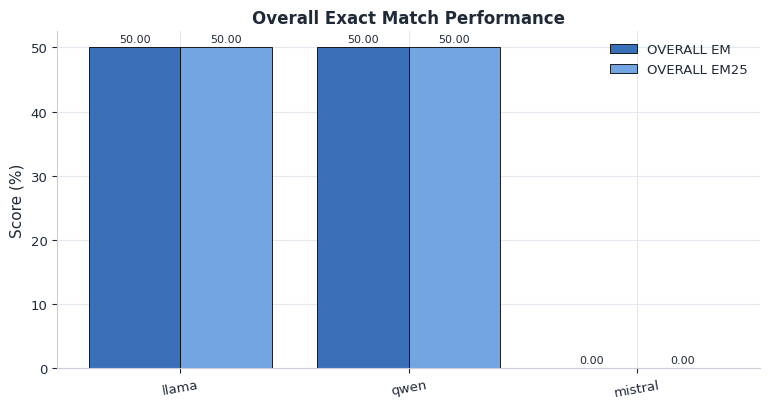

Saved: arabicaqa_rag_results/predictions/figures\plot_overall_em_em25.png
Saved: arabicaqa_rag_results/predictions/figures\plot_overall_em_em25.pdf


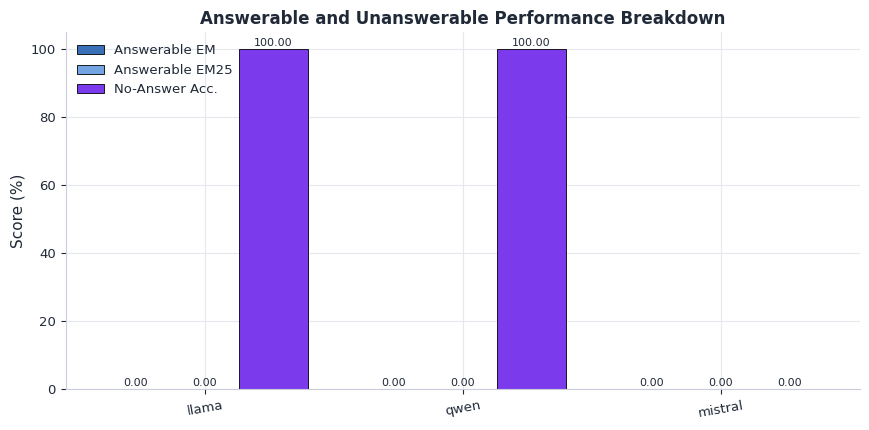

Saved: arabicaqa_rag_results/predictions/figures\plot_breakdown_answerable_noanswer.png
Saved: arabicaqa_rag_results/predictions/figures\plot_breakdown_answerable_noanswer.pdf


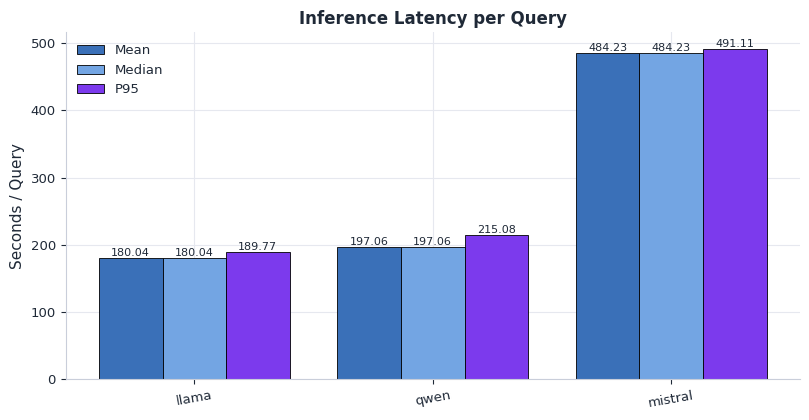

Saved: arabicaqa_rag_results/predictions/figures\plot_inference_latency.png
Saved: arabicaqa_rag_results/predictions/figures\plot_inference_latency.pdf


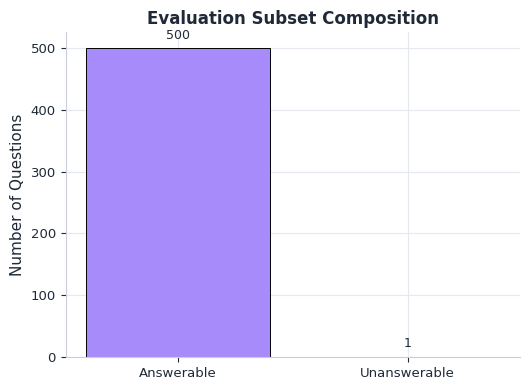

Saved: arabicaqa_rag_results/predictions/figures\plot_dataset_split.png
Saved: arabicaqa_rag_results/predictions/figures\plot_dataset_split.pdf

Done. Figures saved in: arabicaqa_rag_results/predictions/figures


In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# Paths
# ======================================================
SCORES_PATH = "arabicaqa_rag_results/predictions/final_scores_llama_mistral_qwen.csv"
OUT_DIR = "arabicaqa_rag_results/predictions/figures"
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(SCORES_PATH):
    raise FileNotFoundError(f"Scores file not found: {SCORES_PATH}")

df = pd.read_csv(SCORES_PATH, encoding="utf-8-sig")

print("Loaded:", SCORES_PATH)
print(df.round(4).to_string(index=False))

# ======================================================
# Theme colors
# ======================================================
PRIMARY   = "#3A70B8"
SECONDARY = "#73A5E3"
ACCENT1   = "#A78BFA"
ACCENT2   = "#7C3AED"
GREEN     = "#0F9D58"
GRID      = "#E6E8EF"
SPINE     = "#C9CEDA"
TXT       = "#1F2937"

MODEL_COLORS = {
    "llama": PRIMARY,
    "mistral": ACCENT2,
    "qwen": GREEN,
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": SPINE,
    "axes.labelcolor": TXT,
    "xtick.color": TXT,
    "ytick.color": TXT,
    "text.color": TXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
})

def finalize(ax):
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)

def savefig(fig, name):
    png_path = os.path.join(OUT_DIR, f"{name}.png")
    pdf_path = os.path.join(OUT_DIR, f"{name}.pdf")

    fig.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", pdf_path)

# ======================================================
# Prepare
# ======================================================
df["model"] = df["model"].astype(str)

models = df["model"].tolist()
model_colors = [MODEL_COLORS.get(m.lower(), "#777777") for m in models]

# ======================================================
# 1) Overall EM / EM25
# ======================================================
metrics = ["overall_em", "overall_em25"]
available_metrics = [m for m in metrics if m in df.columns]

if available_metrics:
    x = np.arange(len(models))
    width = 0.8 / len(available_metrics)

    fig, ax = plt.subplots(figsize=(7.8, 4.2))

    metric_colors = [PRIMARY, SECONDARY]

    for i, metric in enumerate(available_metrics):
        values = df[metric].astype(float).values
        offset = (i - (len(available_metrics) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=metric.replace("_", " ").upper(),
            color=metric_colors[i],
            edgecolor="black",
            linewidth=0.6
        )

        for j, v in enumerate(values):
            ax.text(
                x[j] + offset,
                v + 0.5,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_ylabel("Score (%)")
    ax.set_title("Overall Exact Match Performance")
    ax.legend(frameon=False)
    finalize(ax)

    savefig(fig, "plot_overall_em_em25")

# ======================================================
# 2) Answerability-aware breakdown
# ======================================================
breakdown_metrics = [
    "answerable_em",
    "answerable_em25",
    "unanswerable_abstention_accuracy",
]
breakdown_metrics = [m for m in breakdown_metrics if m in df.columns]

if breakdown_metrics:
    x = np.arange(len(models))
    width = 0.8 / len(breakdown_metrics)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))

    metric_colors = [PRIMARY, SECONDARY, ACCENT2]

    pretty_names = {
        "answerable_em": "Answerable EM",
        "answerable_em25": "Answerable EM25",
        "unanswerable_abstention_accuracy": "No-Answer Acc.",
    }

    for i, metric in enumerate(breakdown_metrics):
        values = df[metric].astype(float).values
        offset = (i - (len(breakdown_metrics) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=pretty_names.get(metric, metric),
            color=metric_colors[i],
            edgecolor="black",
            linewidth=0.6
        )

        for j, v in enumerate(values):
            ax.text(
                x[j] + offset,
                v + 0.5,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_ylabel("Score (%)")
    ax.set_title("Answerable and Unanswerable Performance Breakdown")
    ax.legend(loc="upper left", frameon=False)
    finalize(ax)

    savefig(fig, "plot_breakdown_answerable_noanswer")

# ======================================================
# 3) Latency plot, if available
# ======================================================
latency_metrics = [
    "latency_mean_sec",
    "latency_median_sec",
    "latency_p95_sec",
]
latency_metrics = [m for m in latency_metrics if m in df.columns]

if latency_metrics:
    x = np.arange(len(models))
    width = 0.8 / len(latency_metrics)

    fig, ax = plt.subplots(figsize=(8.2, 4.3))

    metric_colors = [PRIMARY, SECONDARY, ACCENT2]

    pretty_names = {
        "latency_mean_sec": "Mean",
        "latency_median_sec": "Median",
        "latency_p95_sec": "P95",
    }

    for i, metric in enumerate(latency_metrics):
        values = df[metric].astype(float).values
        offset = (i - (len(latency_metrics) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=pretty_names.get(metric, metric),
            color=metric_colors[i],
            edgecolor="black",
            linewidth=0.6
        )

        for j, v in enumerate(values):
            ax.text(
                x[j] + offset,
                v + 0.03,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_ylabel("Seconds / Query")
    ax.set_title("Inference Latency per Query")
    ax.legend(frameon=False)
    finalize(ax)

    savefig(fig, "plot_inference_latency")

# ======================================================
# 4) Dataset split plot
# ======================================================
if "unanswerable_total" in df.columns:
    # total unanswerable is repeated per model, so take first row
    unanswerable = int(df["unanswerable_total"].iloc[0])

    # If the full total exists indirectly, use n from no-answer total only.
    # Otherwise, infer answerable from known 1000-sample setting if needed.
    if "n_questions" in df.columns:
        total = int(df["n_questions"].iloc[0])
        answerable = total - unanswerable
    else:
        # Your current fixed subset is 500/500.
        answerable = 500

    labels = ["Answerable", "Unanswerable"]
    values = [answerable, unanswerable]

    fig, ax = plt.subplots(figsize=(5.4, 4.0))

    ax.bar(
        labels,
        values,
        color=[ACCENT1, ACCENT2],
        edgecolor="black",
        linewidth=0.7
    )

    for i, v in enumerate(values):
        ax.text(i, v + 10, str(v), ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Number of Questions")
    ax.set_title("Evaluation Subset Composition")
    finalize(ax)

    savefig(fig, "plot_dataset_split")

print("\nDone. Figures saved in:", OUT_DIR)

In [18]:
import os
import ast
import json
import math
import pandas as pd

# ============================================================
# Clean prediction file after generation
# ============================================================

PRED_DIR = "arabicaqa_rag_results/predictions"

INPUT_FILE = "comparison_llama_mistral_qwen_1000.csv"
OUTPUT_FILE = "comparison_llama_mistral_qwen_1000_clean.csv"

input_path = os.path.join(PRED_DIR, INPUT_FILE)
output_path = os.path.join(PRED_DIR, OUTPUT_FILE)

if not os.path.exists(input_path):
    raise FileNotFoundError(f"File not found: {input_path}")

df = pd.read_csv(input_path, encoding="utf-8-sig")

print("=" * 80)
print("CLEANING PREDICTION FILE")
print("=" * 80)
print("Loaded:", input_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# ============================================================
# Robust parsers
# ============================================================
def parse_correct_answers(x):
    """
    Converts correct_answers to list[str].
    Handles:
    - NaN / None
    - Python list
    - stringified list: "['answer']"
    - JSON list: '["answer"]'
    - plain string answer
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        # Try JSON first
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            if str(parsed).strip():
                return [str(parsed).strip()]
        except Exception:
            pass

        # Try Python literal
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            if str(parsed).strip():
                return [str(parsed).strip()]
        except Exception:
            pass

        # Fallback: plain string
        return [s]

    return []

def parse_maybe_list(x):
    """
    Generic parser for columns such as retrieved_contexts or retrieved_doc_ids.
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        return [s]

    return [x]

# ============================================================
# Clean required columns
# ============================================================
if "correct_answers" not in df.columns:
    raise KeyError("Missing column: correct_answers")

df["correct_answers"] = df["correct_answers"].apply(parse_correct_answers)

if "is_impossible" in df.columns:
    df["is_impossible"] = df["is_impossible"].astype(bool)
    df["is_answerable"] = ~df["is_impossible"]

# Optional list-like columns
for col in ["retrieved_contexts", "retrieved_doc_ids"]:
    if col in df.columns:
        df[col] = df[col].apply(parse_maybe_list)

# ============================================================
# Detect model prediction and latency columns
# ============================================================
model_keys = [
    c.replace("predicted_answer_", "")
    for c in df.columns
    if c.startswith("predicted_answer_")
]

print("\nDetected models:")
for m in model_keys:
    print(" -", m)

for m in model_keys:
    pred_col = f"predicted_answer_{m}"
    df[pred_col] = df[pred_col].fillna("").astype(str)

    latency_col = f"latency_sec_{m}"
    if latency_col in df.columns:
        df[latency_col] = pd.to_numeric(df[latency_col], errors="coerce")

# ============================================================
# Integrity checks
# ============================================================
def is_empty_gold(x):
    if x is None:
        return True

    if isinstance(x, float) and math.isnan(x):
        return True

    if isinstance(x, (list, tuple)):
        return len([str(t).strip() for t in x if str(t).strip()]) == 0

    return str(x).strip() == ""

empty_mask = df["correct_answers"].apply(is_empty_gold)

print("\nGold answer integrity:")
print("Empty gold count:", int(empty_mask.sum()))
print("Empty gold %:", round(empty_mask.mean() * 100, 2))

if "is_impossible" in df.columns:
    empty_gold_but_answerable = int((empty_mask & (df["is_impossible"] == False)).sum())
    nonempty_gold_but_unanswerable = int(((~empty_mask) & (df["is_impossible"] == True)).sum())

    print("Empty gold but is_impossible=False:", empty_gold_but_answerable)
    print("Non-empty gold but is_impossible=True:", nonempty_gold_but_unanswerable)

# Error counts
print("\nPrediction error counts:")
for m in model_keys:
    pred_col = f"predicted_answer_{m}"
    n_errors = int((df[pred_col].fillna("") == "ERROR").sum())
    print(f"{m}: {n_errors}")

# ============================================================
# Save clean CSV + JSONL
# ============================================================
df.to_csv(output_path, index=False, encoding="utf-8-sig")

jsonl_path = output_path.replace(".csv", ".jsonl")
df.to_json(jsonl_path, orient="records", lines=True, force_ascii=False)

print("\nSaved clean files:")
print("CSV :", output_path)
print("JSONL:", jsonl_path)

# ============================================================
# Re-read check
# ============================================================
df_check = pd.read_csv(output_path, encoding="utf-8-sig")
df_check["correct_answers"] = df_check["correct_answers"].apply(parse_correct_answers)

print("\nRe-read check:")
print(df_check["correct_answers"].apply(type).value_counts())
print("Shape:", df_check.shape)

df_check.head(3)

CLEANING PREDICTION FILE
Loaded: arabicaqa_rag_results/predictions\comparison_llama_mistral_qwen_1000.csv
Shape: (2, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral', 'predicted_answer_qwen', 'latency_sec_qwen', 'error_qwen']

Detected models:
 - llama
 - mistral
 - qwen

Gold answer integrity:
Empty gold count: 1
Empty gold %: 50.0
Empty gold but is_impossible=False: 0
Non-empty gold but is_impossible=True: 0

Prediction error counts:
llama: 0
mistral: 0
qwen: 0

Saved clean files:
CSV : arabicaqa_rag_results/predictions\comparison_llama_mistral_qwen_1000_clean.csv
JSONL: arabicaqa_rag_results/predictions\comparison_llama_mistral_qwen_1000_clean.jsonl

Re-read check:
correct_answers
<class 'list'>    2
N

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral,predicted_answer_qwen,latency_sec_qwen,error_qwen
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 4, 4, 4, 4]",غير موجود في السياق.,190.849487,NaN,لم يتم بناء الموقع الأول لشركة توب غولف حتى عا...,491.875089,NaN,غير موجود في السياق.,217.083988,NaN
1,1,train,1450918,967260,ما هي التحديات التي واجهها رؤوف دنكتاش خلال فت...,رؤوف دنكتاش (27 يناير 1924 - 13 يناير 2012) كا...,[],True,False,['في أواخر الـ 1960، تدهورت قدراته البدنية: بد...,...,"[8, 8, 8, 8, 8]",غير موجود في السياق.,169.233484,NaN,التحديات التي واجهها رؤوف دنكتاش خلال فترة رئا...,476.583162,NaN,غير موجود في السياق.,177.043332,NaN


In [20]:
%pip install "ragas==0.1.7"

Note: you may need to restart the kernel to use updated packages.


## **RAGAS Part**

In [ ]:
import os
import ast
import json
import math
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import Dataset

from ragas import evaluate
import ragas.metrics as rm

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.chat_models import ChatOllama

# ============================================================
# 0) PATHS
# ============================================================
PRED_PATH = "arabicaqa_rag_results/predictions/comparison_llama_mistral_qwen_1000.csv"
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_qwen"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(PRED_PATH):
    raise FileNotFoundError(f"Prediction file not found: {PRED_PATH}")

TEST_MODE = True

df_results = pd.read_csv(PRED_PATH, encoding="utf-8-sig")
df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

if TEST_MODE:
    df_ans = df_results[df_results["is_impossible"] == False].head(1)
    df_un = df_results[df_results["is_impossible"] == True].head(1)
    df_results = pd.concat([df_ans, df_un], ignore_index=True)
    print(f"TEST MODE: running {len(df_results)} rows")
    print(df_results["is_impossible"].value_counts())

print("=" * 100)
print("RAGAS FULL EVALUATION")
print("=" * 100)
print("Loaded:", PRED_PATH)
print("Shape:", df_results.shape)
print("Columns:", list(df_results.columns))

# ============================================================
# 1) DETECT MODELS AUTOMATICALLY
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if not model_keys:
    raise ValueError("No predicted_answer_* columns found.")

print("\nDetected models:")
for m in model_keys:
    print(f" - {m}")

required_cols = ["question", "correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# 2) PARSE CORRECT ANSWERS
# ============================================================
NO_ANSWER = "غير موجود في السياق"

def parse_correct_answers(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            return [str(parsed).strip()] if str(parsed).strip() else []
        except Exception:
            return [s]

    return []

df_results["correct_answers"] = df_results["correct_answers"].apply(parse_correct_answers)
df_results["is_impossible"] = df_results["is_impossible"].astype(bool)
df_results["is_answerable"] = ~df_results["is_impossible"]

# RAGAS usually expects a single ground_truth string.
# We use the first canonical answer where available.
# For unanswerable questions, we use the no-answer label.
def get_ground_truth(ans_list, is_impossible):
    if is_impossible:
        return NO_ANSWER

    if isinstance(ans_list, list) and len(ans_list) > 0:
        return str(ans_list[0]).strip()

    return ""

df_results["ground_truth_for_ragas"] = df_results.apply(
    lambda r: get_ground_truth(r["correct_answers"], r["is_impossible"]),
    axis=1
)

print("\nAnswerability counts:")
print(df_results["is_answerable"].value_counts())

# ============================================================
# 3) CONTEXTS
# ============================================================
TOP_K = 5

def try_parse_contexts(x):
    """
    Ensures contexts are list[str].
    Handles:
    - real list
    - stringified list
    - plain string context
    - empty/missing context
    """
    if x is None:
        return [""]

    if isinstance(x, float) and math.isnan(x):
        return [""]

    if isinstance(x, list):
        if len(x) == 0:
            return [""]
        return [str(c) for c in x]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return [""]

        # If it looks like a list, parse it.
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    cleaned = [str(c) for c in parsed if str(c).strip()]
                    return cleaned if cleaned else [""]
            except Exception:
                pass

        # Otherwise treat the whole string as one context.
        return [s]

    return [str(x)]

if "retrieved_contexts" in df_results.columns:
    print("\nUsing existing retrieved_contexts column.")
    df_results["retrieved_contexts"] = df_results["retrieved_contexts"].apply(try_parse_contexts)

else:
    print("\nNo retrieved_contexts column found.")

    if "context" in df_results.columns:
        print("Using existing context column as a single retrieved context.")
        df_results["retrieved_contexts"] = df_results["context"].apply(try_parse_contexts)

    else:
        print("No context column found. Re-retrieving contexts using existing retriever object.")

        contexts_list = []
        for q in tqdm(df_results["question"].fillna("").astype(str).tolist(), desc="Retrieving contexts"):
            docs = retriever.invoke(q)  # assumes retriever exists in notebook
            contexts_list.append([d.page_content for d in docs[:TOP_K]])

        df_results["retrieved_contexts"] = contexts_list

# Save the prediction file with retrieved_contexts included for reproducibility.
contexts_augmented_path = os.path.join(OUTPUT_DIR, "predictions_with_retrieved_contexts.csv")
df_results.to_csv(contexts_augmented_path, index=False, encoding="utf-8-sig")
print("Saved contexts-augmented predictions:", contexts_augmented_path)

# ============================================================
# 4) RAGAS METRICS
# ============================================================
metric_candidates = [
    getattr(rm, "answer_relevancy", None),
    getattr(rm, "faithfulness", None),
    getattr(rm, "context_recall", None),
    getattr(rm, "context_precision", None),
    getattr(rm, "context_relevancy", None) or getattr(rm, "context_relevance", None),
    getattr(rm, "answer_correctness", None),
    getattr(rm, "answer_similarity", None),
]

metrics = [m for m in metric_candidates if m is not None]

if not metrics:
    raise RuntimeError("No compatible RAGAS metrics were found in the installed ragas version.")

metric_names = [m.name for m in metrics]

print("\nRAGAS metrics that will run:")
for name in metric_names:
    print(f" - {name}")

# ============================================================
# 5) JUDGE LLM + EMBEDDINGS
# ============================================================
embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-large"
)

llm_ragas = ChatOllama(
    model="gemma2:2b",
    temperature=0.0,
    base_url="http://127.0.0.1:11434",
    format="json",
)

print("\nJudge LLM: gemma2:2b via Ollama")
print("Embeddings: intfloat/multilingual-e5-large")

# ============================================================
# 6) HELPER: RUN RAGAS FOR ONE MODEL
# ============================================================
def run_ragas_for_model(df_input, model_key):
    pred_col = f"predicted_answer_{model_key}"

    if pred_col not in df_input.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    df_eval = df_input.copy()

    ragas_dataset = Dataset.from_dict({
        "question": df_eval["question"].fillna("").astype(str).tolist(),
        "answer": df_eval[pred_col].fillna("").astype(str).tolist(),
        "contexts": df_eval["retrieved_contexts"].tolist(),
        "ground_truth": df_eval["ground_truth_for_ragas"].fillna("").astype(str).tolist(),
    })

    start_time = time.perf_counter()

    result = evaluate(
        ragas_dataset,
        metrics=metrics,
        llm=llm_ragas,
        embeddings=embeddings,
        raise_exceptions=False,
    )

    end_time = time.perf_counter()
    total_latency_sec = end_time - start_time
    avg_latency_sec = total_latency_sec / len(df_eval) if len(df_eval) else np.nan

    df_scores = result.to_pandas()

    # Coerce metric columns to numeric if needed
    non_metric_cols = {"question", "answer", "contexts", "ground_truth"}
    for c in df_scores.columns:
        if c not in non_metric_cols:
            df_scores[c] = pd.to_numeric(df_scores[c], errors="coerce")

    # Build per-question result table
    out = pd.DataFrame({
        "row_idx": df_eval["row_idx"].values if "row_idx" in df_eval.columns else df_eval.index.values,
        "question_id": df_eval["question_id"].values if "question_id" in df_eval.columns else "",
        "document_id": df_eval["document_id"].values if "document_id" in df_eval.columns else "",
        "question": df_eval["question"].values,
        "is_impossible": df_eval["is_impossible"].values,
        "is_answerable": df_eval["is_answerable"].values,
        "ground_truth": df_eval["ground_truth_for_ragas"].values,
        "model": model_key,
        "answer": df_eval[pred_col].fillna("").astype(str).values,
        "retrieved_contexts": df_eval["retrieved_contexts"].values,
    })

    # Add generation latency from prediction file, if available
    gen_latency_col = f"latency_sec_{model_key}"
    if gen_latency_col in df_eval.columns:
        out["generation_latency_sec"] = pd.to_numeric(df_eval[gen_latency_col], errors="coerce").values
    else:
        out["generation_latency_sec"] = np.nan

    # RAGAS latency is measured at model-run level, then averaged per question.
    # This is the best estimate unless RAGAS is run one question at a time.
    out["ragas_total_run_latency_sec"] = total_latency_sec
    out["ragas_avg_latency_sec_per_question"] = avg_latency_sec

    # Add RAGAS metric columns
    for c in df_scores.columns:
        if c not in non_metric_cols:
            out[c] = df_scores[c].values

    return out, total_latency_sec, avg_latency_sec

# ============================================================
# 7) RUN RAGAS FOR ALL MODELS
# ============================================================
all_per_question = []
run_latency_rows = []

for model_key in model_keys:
    print("\n" + "=" * 100)
    print(f"Running RAGAS for model: {model_key.upper()}")
    print("=" * 100)

    df_model_scores, total_lat, avg_lat = run_ragas_for_model(df_results, model_key)

    all_per_question.append(df_model_scores)

    run_latency_rows.append({
        "model": model_key,
        "n_questions": int(len(df_results)),
        "ragas_total_latency_sec": float(total_lat),
        "ragas_avg_latency_sec_per_question": float(avg_lat),
    })

    per_model_path = os.path.join(OUTPUT_DIR, f"ragas_per_question_{model_key}.csv")
    df_model_scores.to_csv(per_model_path, index=False, encoding="utf-8-sig")

    print(f"Saved per-question RAGAS for {model_key}: {per_model_path}")
    print(f"RAGAS total latency: {total_lat:.2f} sec")
    print(f"RAGAS avg latency/question: {avg_lat:.4f} sec")

df_per_question = pd.concat(all_per_question, ignore_index=True)

per_question_csv = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models.csv")
per_question_json = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models.json")

df_per_question.to_csv(per_question_csv, index=False, encoding="utf-8-sig")
df_per_question.to_json(per_question_json, orient="records", force_ascii=False, indent=2)

print("\nSaved combined per-question RAGAS:")
print("CSV :", per_question_csv)
print("JSON:", per_question_json)

# ============================================================
# 8) AGGREGATE MEANS: ALL / ANSWERABLE / UNANSWERABLE
# ============================================================
metadata_cols = {
    "row_idx",
    "question_id",
    "document_id",
    "question",
    "is_impossible",
    "is_answerable",
    "ground_truth",
    "model",
    "answer",
    "retrieved_contexts",
    "generation_latency_sec",
    "ragas_total_run_latency_sec",
    "ragas_avg_latency_sec_per_question",
}

candidate_metric_cols = [
    c for c in df_per_question.columns
    if c not in metadata_cols
]

# Keep numeric metric columns only
metric_cols = []
for c in candidate_metric_cols:
    df_per_question[c] = pd.to_numeric(df_per_question[c], errors="coerce")
    if pd.api.types.is_numeric_dtype(df_per_question[c]):
        metric_cols.append(c)

summary_rows = []

def summarize_subset(df_sub, subset_name):
    for model_key in model_keys:
        df_m = df_sub[df_sub["model"] == model_key].copy()

        if len(df_m) == 0:
            continue

        row = {
            "model": model_key,
            "subset": subset_name,
            "n_questions": int(len(df_m)),
            "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
            "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
            "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
            "ragas_avg_latency_sec_per_question": float(df_m["ragas_avg_latency_sec_per_question"].mean(skipna=True)),
        }

        for m in metric_cols:
            row[m] = float(df_m[m].mean(skipna=True))

        summary_rows.append(row)

summarize_subset(df_per_question, "ALL")
summarize_subset(df_per_question[df_per_question["is_answerable"] == True], "ANSWERABLE")
summarize_subset(df_per_question[df_per_question["is_answerable"] == False], "UNANSWERABLE")

df_summary = pd.DataFrame(summary_rows)

summary_csv = os.path.join(OUTPUT_DIR, "ragas_summary_means.csv")
summary_json = os.path.join(OUTPUT_DIR, "ragas_summary_means.json")
summary_md = os.path.join(OUTPUT_DIR, "RAGAS_SUMMARY.md")

df_summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")
df_summary.to_json(summary_json, orient="records", force_ascii=False, indent=2)

with open(summary_md, "w", encoding="utf-8") as f:
    f.write("# RAGAS Summary Means\n\n")
    f.write("Judge LLM: `gemma2:2b` via Ollama  \n")
    f.write("Embeddings: `intfloat/multilingual-e5-large`  \n")
    f.write(f"Prediction file: `{PRED_PATH}`  \n\n")
    try:
        f.write(df_summary.round(4).to_markdown(index=False))
    except Exception:
        f.write(df_summary.round(4).to_string(index=False))

print("\nSaved RAGAS summaries:")
print("CSV :", summary_csv)
print("JSON:", summary_json)
print("MD  :", summary_md)

# ============================================================
# 9) NaN DIAGNOSTICS
# ============================================================
nan_rows = []

for model_key in model_keys:
    for subset_name, df_sub in [
        ("ALL", df_per_question),
        ("ANSWERABLE", df_per_question[df_per_question["is_answerable"] == True]),
        ("UNANSWERABLE", df_per_question[df_per_question["is_answerable"] == False]),
    ]:
        df_m = df_sub[df_sub["model"] == model_key]

        for m in metric_cols:
            nan_count = int(df_m[m].isna().sum())
            n = int(len(df_m))
            nan_rows.append({
                "model": model_key,
                "subset": subset_name,
                "metric": m,
                "nan_count": nan_count,
                "n_questions": n,
                "nan_ratio": float(nan_count / n) if n > 0 else np.nan,
            })

df_nan = pd.DataFrame(nan_rows)

nan_csv = os.path.join(OUTPUT_DIR, "ragas_nan_report.csv")
nan_json = os.path.join(OUTPUT_DIR, "ragas_nan_report.json")

df_nan.to_csv(nan_csv, index=False, encoding="utf-8-sig")
df_nan.to_json(nan_json, orient="records", force_ascii=False, indent=2)

print("\nSaved NaN diagnostics:")
print("CSV :", nan_csv)
print("JSON:", nan_json)

# ============================================================
# 10) LATENCY SUMMARY
# ============================================================
df_ragas_latency = pd.DataFrame(run_latency_rows)

latency_rows = []

for model_key in model_keys:
    df_m = df_per_question[df_per_question["model"] == model_key].copy()

    row = {
        "model": model_key,
        "n_questions": int(len(df_m)),
        "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
        "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
        "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
        "ragas_avg_latency_sec_per_question": float(df_m["ragas_avg_latency_sec_per_question"].mean(skipna=True)),
    }

    latency_rows.append(row)

df_latency_summary = pd.DataFrame(latency_rows)

latency_summary_csv = os.path.join(OUTPUT_DIR, "latency_summary.csv")
ragas_latency_csv = os.path.join(OUTPUT_DIR, "ragas_run_latency.csv")

df_latency_summary.to_csv(latency_summary_csv, index=False, encoding="utf-8-sig")
df_ragas_latency.to_csv(ragas_latency_csv, index=False, encoding="utf-8-sig")

print("\nSaved latency summaries:")
print("Generation + RAGAS latency:", latency_summary_csv)
print("RAGAS run latency:", ragas_latency_csv)

# ============================================================
# 11) FINAL PRINT
# ============================================================
print("\n" + "=" * 100)
print("FINAL RAGAS SUMMARY")
print("=" * 100)

try:
    display(df_summary.round(4))
except Exception:
    print(df_summary.round(4).to_string(index=False))

print("\n" + "=" * 100)
print("LATENCY SUMMARY")
print("=" * 100)

try:
    display(df_latency_summary.round(4))
except Exception:
    print(df_latency_summary.round(4).to_string(index=False))

print("\nDone.")

TEST MODE: running 2 rows
is_impossible
False    1
True     1
Name: count, dtype: int64
RAGAS FULL EVALUATION
Loaded: arabicaqa_rag_results/predictions/comparison_llama_mistral_qwen_1000.csv
Shape: (2, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral', 'predicted_answer_qwen', 'latency_sec_qwen', 'error_qwen']

Detected models:
 - llama
 - mistral
 - qwen

Answerability counts:
is_answerable
True     1
False    1
Name: count, dtype: int64

Using existing retrieved_contexts column.
Saved contexts-augmented predictions: arabicaqa_rag_results/ragas_full_llama_mistral_qwen\predictions_with_retrieved_contexts.csv

RAGAS metrics that will run:
 - answer_relevancy
 - faithfulness
 - context_recall
 - context_prec

c:\Users\Zohoor Almalki\Projects\NLP\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Zohoor Almalki\.cache\huggingface\hub\models--intfloat--multilingual-e5-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [25]:
import sys
import importlib.metadata as md

print("Python executable used by this kernel:")
print(sys.executable)

packages = [
    "ragas",
    "langchain",
    "langchain-community",
    "langchain-core",
    "langchain-openai",
    "langchain-text-splitters",
    "langchain-ollama",
    "pydantic",
    "datasets",
]

print("\nInstalled versions:")
for pkg in packages:
    try:
        print(f"{pkg:28s} {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"{pkg:28s} NOT INSTALLED")

Python executable used by this kernel:
c:\Users\Zohoor Almalki\Projects\NLP\.venv\Scripts\python.exe

Installed versions:
ragas                        0.4.1
langchain                    1.2.17
langchain-community          0.4.1
langchain-core               1.3.2
langchain-openai             1.2.1
langchain-text-splitters     1.1.2
langchain-ollama             NOT INSTALLED
pydantic                     2.13.3
datasets                     4.8.5


The experiments were executed on Lambda Cloud using a single NVIDIA A100 GPU, with long-running jobs managed via terminal session multiplexing (tmux) to ensure uninterrupted execution in the event of network or SSH disconnections.

The total session duration was approximately 15 hours and 59 minutes, of which 14–15 hours were dedicated to running the RAGAS evaluation pipeline, while the remaining time was used for environment setup and code execution on the Lambda instance. During the final 1–2 hours of execution, the internet connection was interrupted, which prevented the outputs from appearing in the interactive notebook interface. However, since the experiment was running inside a tmux session, the Lambda server successfully completed the execution and all results were generated and saved correctly.

Loaded results: (4, 9)
  model       subset  n_questions  answer_relevancy  faithfulness  context_recall  context_precision  answer_correctness  answer_similarity
  LLAMA   ANSWERABLE          500            0.5866        0.8111          0.6087             0.2386              0.5820             0.8396
  LLAMA UNANSWERABLE          500            0.6758        0.7993          0.8991             0.0480              0.5057             0.7497
MISTRAL   ANSWERABLE          500            0.5027        0.8614          0.6096             0.2309              0.5218             0.8231
MISTRAL UNANSWERABLE          500            0.6078        0.8381          0.9054             0.0476              0.4899             0.7401

Loaded NaN report: (24, 6)
model       subset             metric  nan_count  n_questions  nan_ratio
LLAMA   ANSWERABLE answer_correctness         12          500      0.024
LLAMA   ANSWERABLE   answer_relevancy          1          500      0.002
LLAMA   ANSWERABLE  answer_sim

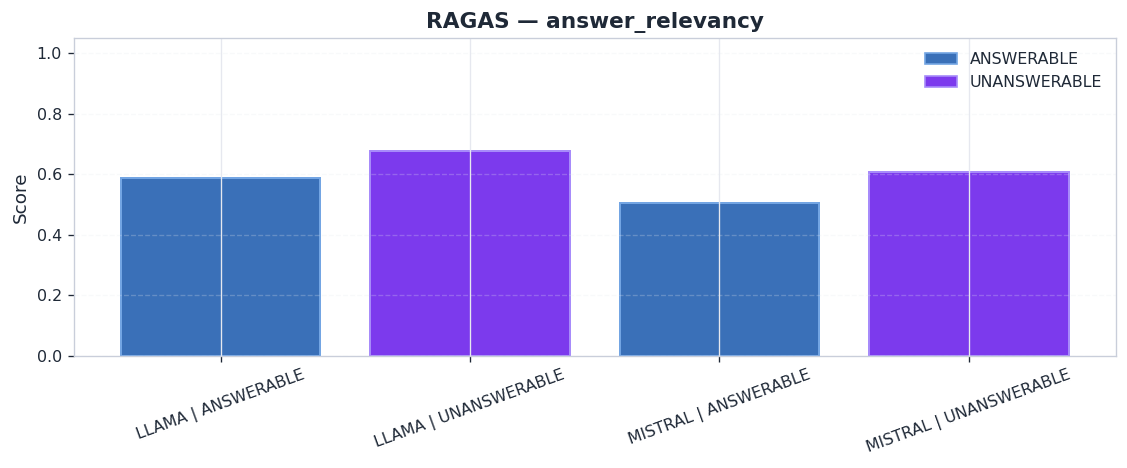

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_answer_relevancy.png


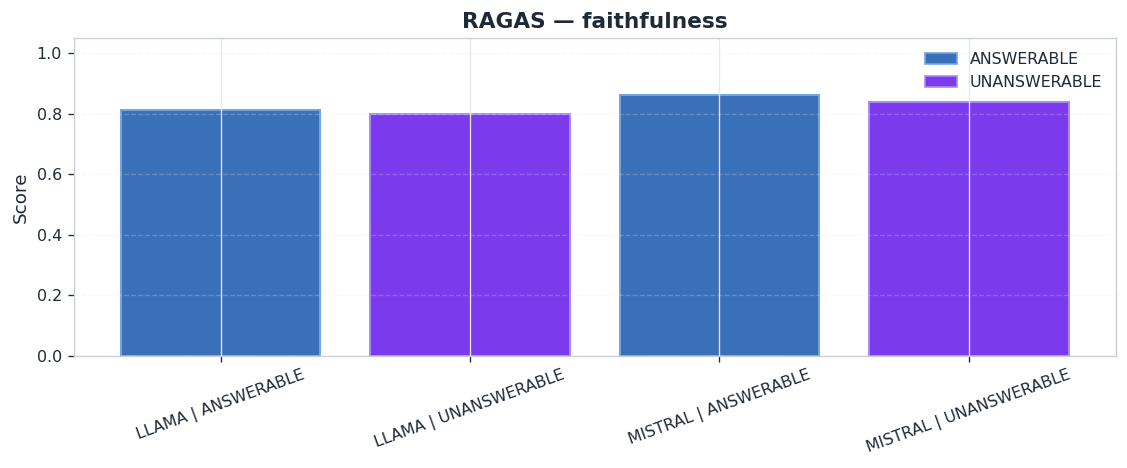

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_faithfulness.png


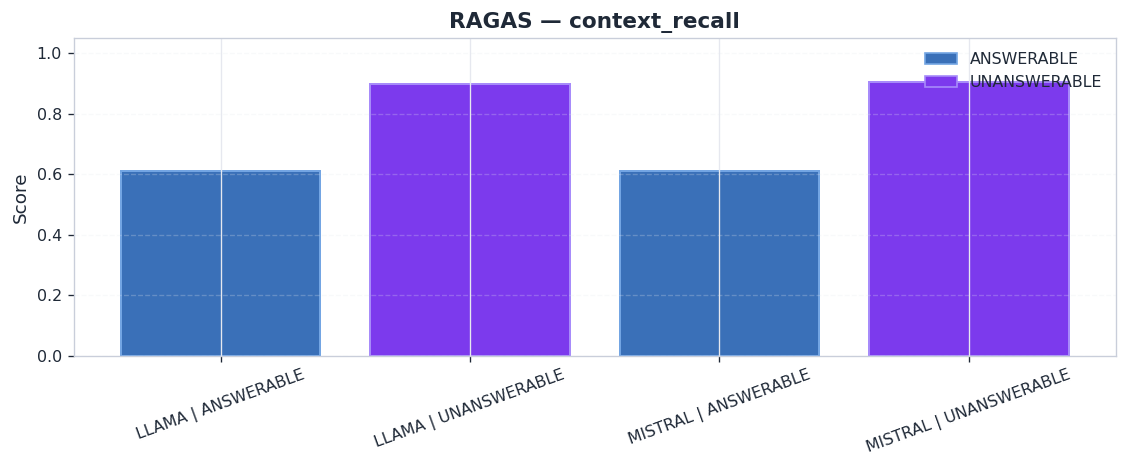

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_context_recall.png


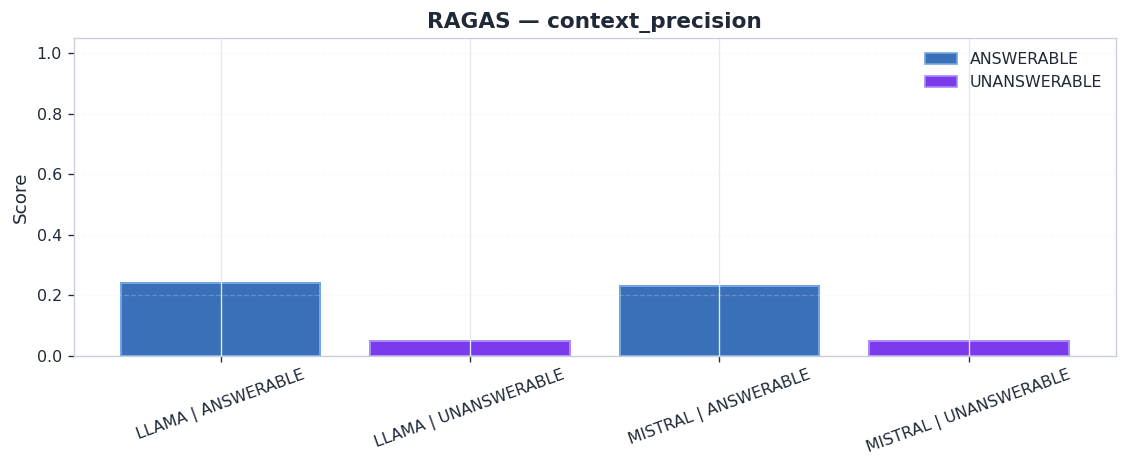

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_context_precision.png


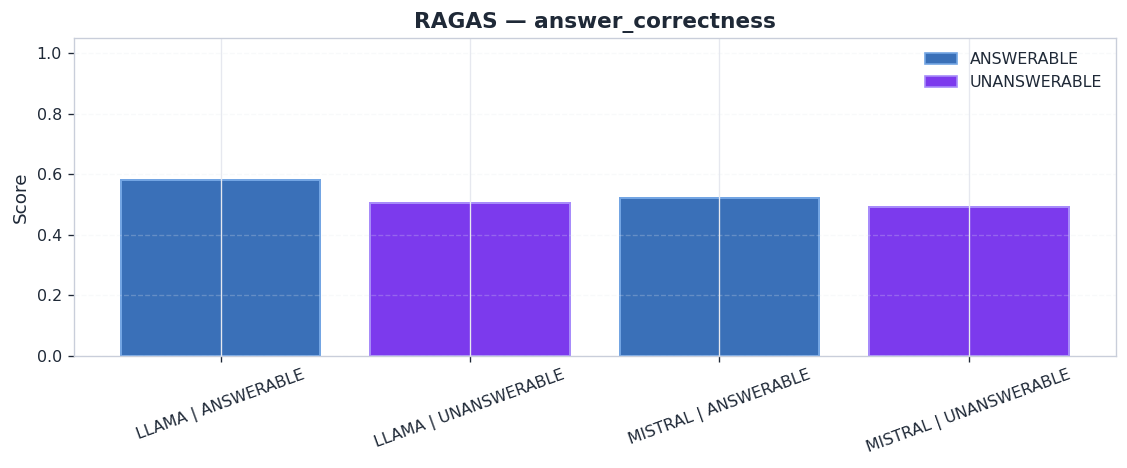

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_answer_correctness.png


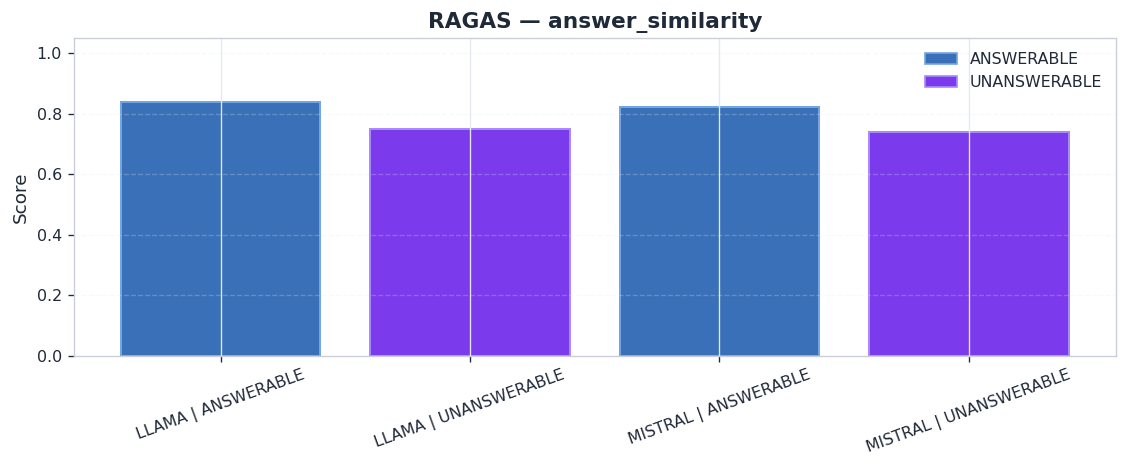

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_answer_similarity.png


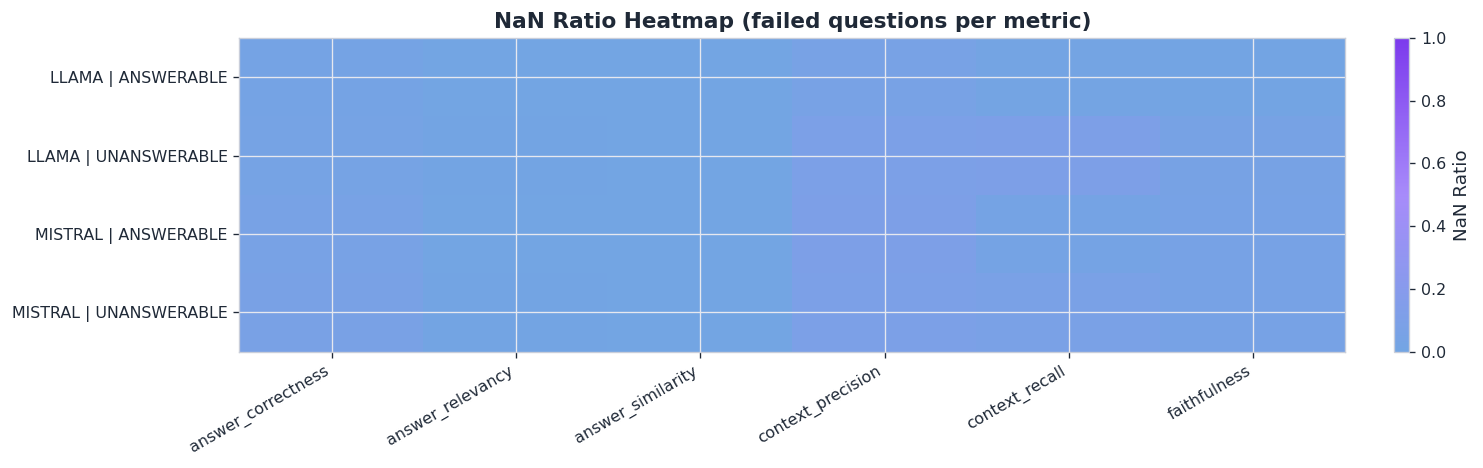

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_nan_heatmap.png


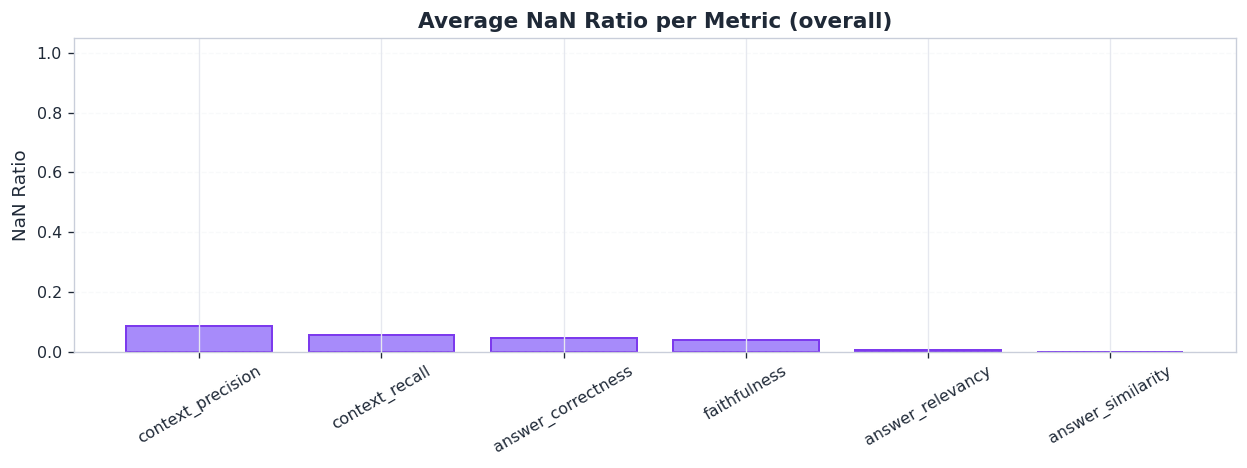

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_nan_ratio_summary.png

Done ✅ Figures saved in: arabicaqa_rag_results/ragas_full\figures


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# 0) Paths
# ============================================================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_qwen"

summary_path = os.path.join(OUTPUT_DIR, "ragas_summary_means.csv")
per_question_path = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models.csv")
nan_path = os.path.join(OUTPUT_DIR, "ragas_nan_report.csv")
latency_path = os.path.join(OUTPUT_DIR, "latency_summary.csv")

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Missing summary file: {summary_path}")

df_summary = pd.read_csv(summary_path, encoding="utf-8-sig")
df_per_question = pd.read_csv(per_question_path, encoding="utf-8-sig") if os.path.exists(per_question_path) else None
df_nan = pd.read_csv(nan_path, encoding="utf-8-sig") if os.path.exists(nan_path) else None
df_latency = pd.read_csv(latency_path, encoding="utf-8-sig") if os.path.exists(latency_path) else None

print("Loaded RAGAS summary:", df_summary.shape)
print(df_summary.round(4).to_string(index=False))

if df_nan is not None:
    print("\nLoaded NaN report:", df_nan.shape)

if df_latency is not None:
    print("\nLoaded latency summary:", df_latency.shape)
    print(df_latency.round(4).to_string(index=False))

# ============================================================
# 1) Plot configuration
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

# Use clear, publication-friendly colors
MODEL_COLORS = {
    "llama": "#3A70B8",
    "mistral": "#7C3AED",
    "qwen": "#0F9D58",
}

SUBSET_ORDER = ["ALL", "ANSWERABLE", "UNANSWERABLE"]

# ============================================================
# 2) Detect RAGAS metric columns
# ============================================================
metadata_cols = {
    "model",
    "subset",
    "n_questions",
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
    "ragas_avg_latency_sec_per_question",
}

metric_cols = [
    c for c in df_summary.columns
    if c not in metadata_cols
]

for c in metric_cols:
    df_summary[c] = pd.to_numeric(df_summary[c], errors="coerce")

metric_cols = [
    c for c in metric_cols
    if df_summary[c].notna().any()
]

print("\nDetected RAGAS metrics:", metric_cols)

# ============================================================
# 3) Figure A: RAGAS metrics for ALL subset only
# Best for main paper
# ============================================================
df_all = df_summary[df_summary["subset"] == "ALL"].copy()

if not df_all.empty:
    for metric in metric_cols:
        fig, ax = plt.subplots(figsize=(7.5, 4.2))

        df_plot = df_all.copy()
        df_plot["model"] = df_plot["model"].astype(str)

        colors = [
            MODEL_COLORS.get(m.lower(), "#777777")
            for m in df_plot["model"]
        ]

        ax.bar(
            df_plot["model"],
            df_plot[metric],
            color=colors,
            edgecolor="black",
            linewidth=0.8
        )

        ax.set_title(f"RAGAS Metric: {metric} (All Questions)")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        for i, value in enumerate(df_plot[metric]):
            if pd.notna(value):
                ax.text(
                    i,
                    value + 0.02,
                    f"{value:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

        plt.tight_layout()

        safe_name = metric.replace("/", "_").replace(" ", "_")
        png_path = os.path.join(FIG_DIR, f"ragas_all_{safe_name}.png")
        pdf_path = os.path.join(FIG_DIR, f"ragas_all_{safe_name}.pdf")

        plt.savefig(png_path, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.show()

        print(f"Saved: {png_path}")

# ============================================================
# 4) Figure B: Grouped bar chart per metric across subsets
# Good for appendix or detailed results
# ============================================================
for metric in metric_cols:
    df_plot = df_summary.copy()
    df_plot = df_plot[df_plot["subset"].isin(SUBSET_ORDER)].copy()

    models = sorted(df_plot["model"].astype(str).unique().tolist())
    subsets = [s for s in SUBSET_ORDER if s in df_plot["subset"].unique()]

    x = np.arange(len(subsets))
    width = 0.8 / max(len(models), 1)

    fig, ax = plt.subplots(figsize=(9.5, 4.5))

    for i, model in enumerate(models):
        values = []
        for subset in subsets:
            val = df_plot[
                (df_plot["model"].astype(str) == model) &
                (df_plot["subset"] == subset)
            ][metric]

            values.append(float(val.iloc[0]) if len(val) else np.nan)

        offset = (i - (len(models) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width,
            label=model,
            color=MODEL_COLORS.get(model.lower(), "#777777"),
            edgecolor="black",
            linewidth=0.7
        )

    ax.set_title(f"RAGAS Metric by Answerability: {metric}")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(subsets)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()

    safe_name = metric.replace("/", "_").replace(" ", "_")
    png_path = os.path.join(FIG_DIR, f"ragas_by_subset_{safe_name}.png")
    pdf_path = os.path.join(FIG_DIR, f"ragas_by_subset_{safe_name}.pdf")

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")

# ============================================================
# 5) Figure C: Latency comparison
# Main paper candidate
# ============================================================
if df_latency is not None and not df_latency.empty:
    latency_cols = [
        "generation_latency_mean_sec",
        "generation_latency_median_sec",
        "generation_latency_p95_sec",
    ]

    for c in latency_cols:
        if c in df_latency.columns:
            df_latency[c] = pd.to_numeric(df_latency[c], errors="coerce")

    fig, ax = plt.subplots(figsize=(8, 4.5))

    df_lat = df_latency.copy()
    df_lat["model"] = df_lat["model"].astype(str)

    x = np.arange(len(df_lat))
    width = 0.25

    ax.bar(
        x - width,
        df_lat["generation_latency_mean_sec"],
        width,
        label="Mean",
        edgecolor="black",
        linewidth=0.7
    )

    ax.bar(
        x,
        df_lat["generation_latency_median_sec"],
        width,
        label="Median",
        edgecolor="black",
        linewidth=0.7
    )

    ax.bar(
        x + width,
        df_lat["generation_latency_p95_sec"],
        width,
        label="P95",
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_title("Inference Latency per Query")
    ax.set_ylabel("Seconds / Query")
    ax.set_xticks(x)
    ax.set_xticklabels(df_lat["model"].tolist())
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()

    png_path = os.path.join(FIG_DIR, "inference_latency_summary.png")
    pdf_path = os.path.join(FIG_DIR, "inference_latency_summary.pdf")

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")

# ============================================================
# 6) Figure D: NaN ratio heatmap
# Diagnostic; better for appendix/supplementary
# ============================================================
if df_nan is not None and not df_nan.empty:
    df_nan2 = df_nan.copy()
    df_nan2["model"] = df_nan2["model"].astype(str)
    df_nan2["subset"] = df_nan2["subset"].astype(str)
    df_nan2["metric"] = df_nan2["metric"].astype(str)

    # Prefer ALL subset for cleaner diagnostics
    df_nan_all = df_nan2[df_nan2["subset"] == "ALL"].copy()
    if df_nan_all.empty:
        df_nan_all = df_nan2.copy()

    pivot = (
        df_nan_all.pivot_table(
            index="model",
            columns="metric",
            values="nan_ratio",
            aggfunc="mean"
        )
        .fillna(0.0)
    )

    fig, ax = plt.subplots(figsize=(12, 3.8))
    im = ax.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)

    ax.set_title("RAGAS NaN Ratio by Model and Metric")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index.tolist())

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.tolist(), rotation=30, ha="right")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.values[i, j]
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("NaN Ratio")

    plt.tight_layout()

    png_path = os.path.join(FIG_DIR, "ragas_nan_heatmap.png")
    pdf_path = os.path.join(FIG_DIR, "ragas_nan_heatmap.pdf")

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")

# ============================================================
# 7) Optional: Per-question score distributions
# Useful if reviewer asks for uncertainty/variation
# ============================================================
if df_per_question is not None and not df_per_question.empty:
    for metric in metric_cols:
        if metric not in df_per_question.columns:
            continue

        df_pq = df_per_question.copy()
        df_pq[metric] = pd.to_numeric(df_pq[metric], errors="coerce")
        df_pq = df_pq.dropna(subset=[metric])

        if df_pq.empty:
            continue

        models = sorted(df_pq["model"].astype(str).unique().tolist())

        fig, ax = plt.subplots(figsize=(8.5, 4.5))

        data = [
            df_pq[df_pq["model"].astype(str) == m][metric].values
            for m in models
        ]

        ax.boxplot(
            data,
            labels=models,
            showmeans=True
        )

        ax.set_title(f"Per-question RAGAS Distribution: {metric}")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        plt.tight_layout()

        safe_name = metric.replace("/", "_").replace(" ", "_")
        png_path = os.path.join(FIG_DIR, f"ragas_distribution_{safe_name}.png")
        pdf_path = os.path.join(FIG_DIR, f"ragas_distribution_{safe_name}.pdf")

        plt.savefig(png_path, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.show()

        print(f"Saved: {png_path}")

print("\nDone. Figures saved in:", FIG_DIR)

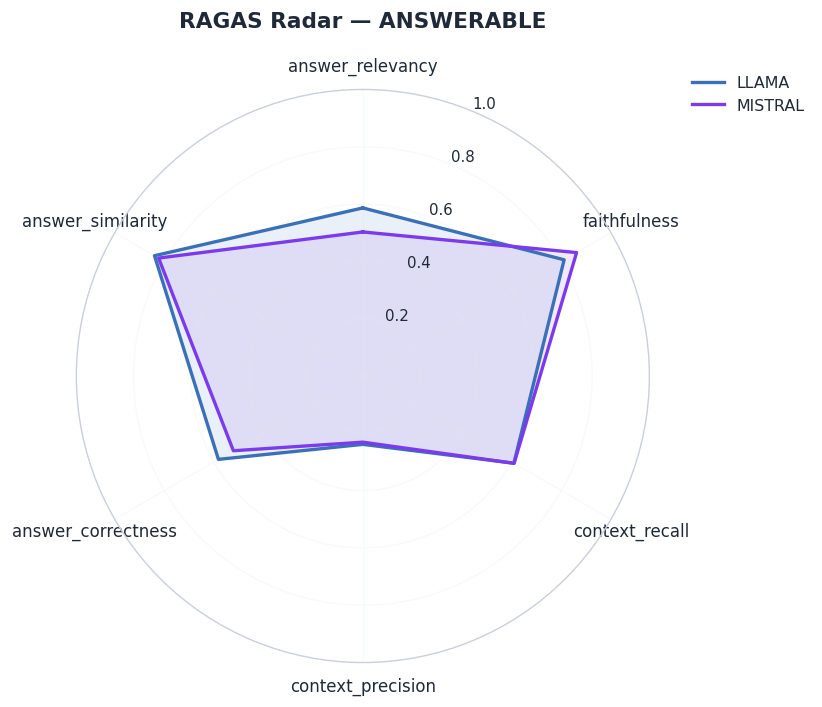

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_radar_answerable.png


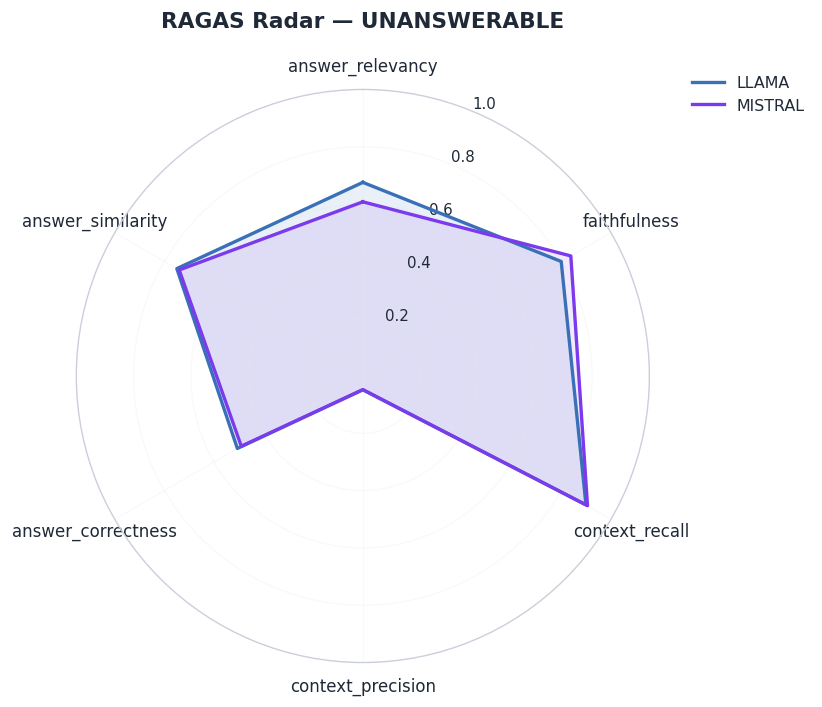

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_radar_unanswerable.png


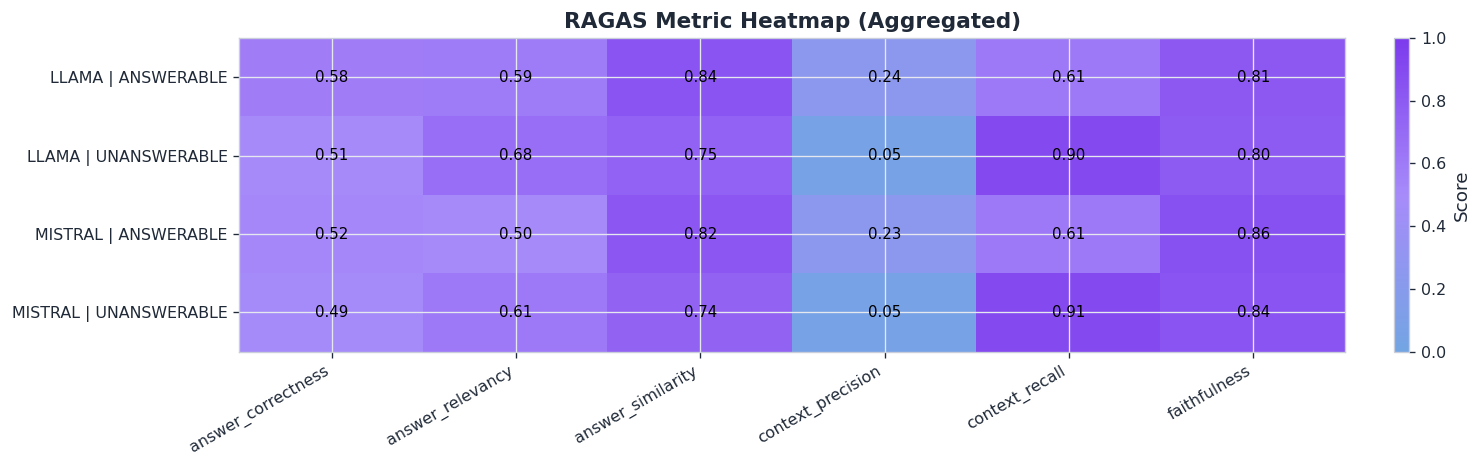

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_metric_heatmap.png


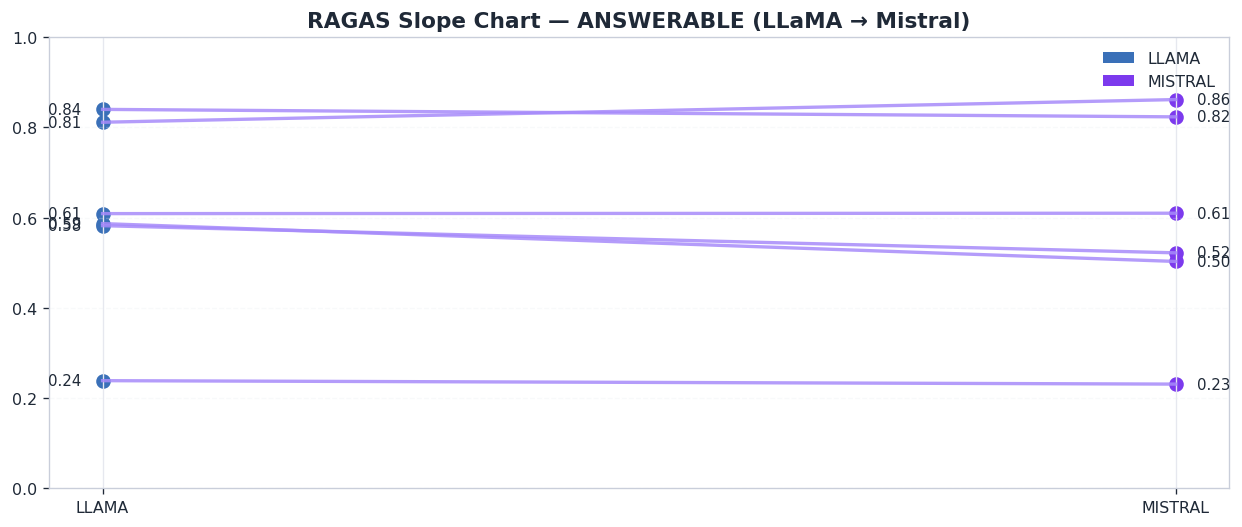

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_slope_answerable.png


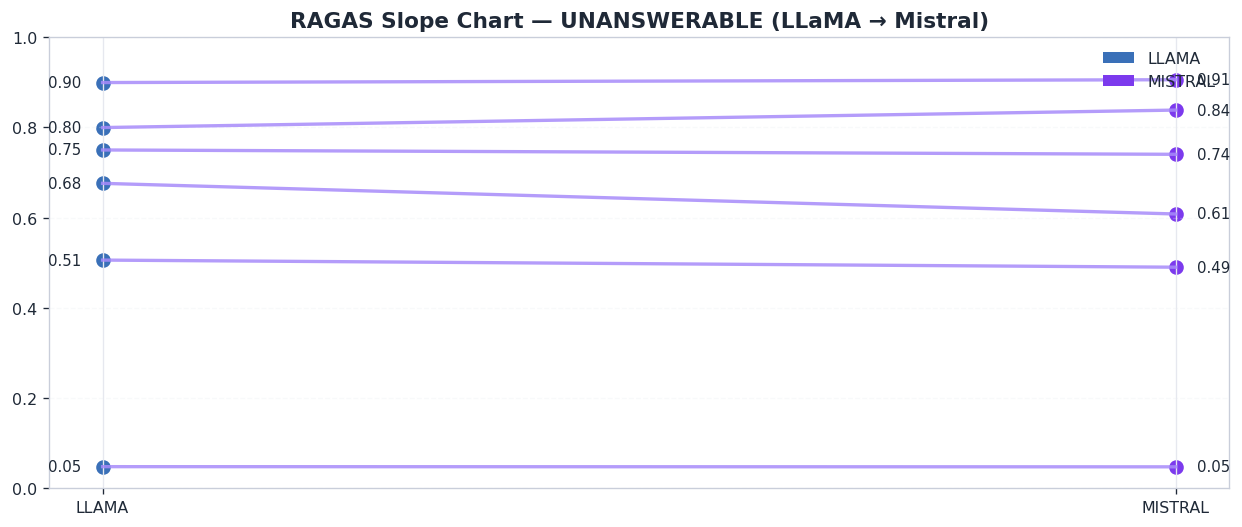

Saved → arabicaqa_rag_results/ragas_full\figures\ragas_slope_unanswerable.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# ============================================================
# 0) Paths
# ============================================================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_qwen"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

summary_path = os.path.join(OUTPUT_DIR, "ragas_summary_means.csv")

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Missing RAGAS summary file: {summary_path}")

df_plot = pd.read_csv(summary_path, encoding="utf-8-sig")

print("Loaded:", summary_path)
print(df_plot.round(4).to_string(index=False))

# ============================================================
# 1) Basic preparation
# ============================================================
df_plot["model"] = df_plot["model"].astype(str)
df_plot["subset"] = df_plot["subset"].astype(str).str.upper()
df_plot["group"] = df_plot["model"] + " | " + df_plot["subset"]

metadata_cols = {
    "model",
    "subset",
    "n_questions",
    "group",
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
    "ragas_avg_latency_sec_per_question",
}

metric_cols = [
    c for c in df_plot.columns
    if c not in metadata_cols
]

for c in metric_cols:
    df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

metric_cols = [
    c for c in metric_cols
    if df_plot[c].notna().any()
]

print("\nDetected metrics:", metric_cols)

if len(metric_cols) == 0:
    raise ValueError("No RAGAS metric columns detected.")

# ============================================================
# 2) Theme / colors
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

MODEL_COLORS = {
    "llama": "#3A70B8",
    "mistral": "#7C3AED",
    "qwen": "#0F9D58",
}

DEFAULT_COLOR = "#777777"

# Colormap for heatmaps
theme_cmap = LinearSegmentedColormap.from_list(
    "theme_cmap_vals",
    ["#E8F0FE", "#A78BFA", "#7C3AED"]
)

SUBSET_ORDER = ["ALL", "ANSWERABLE", "UNANSWERABLE"]

# ============================================================
# 3) Radar chart for one subset
# ============================================================
def radar_chart_for_subset(df_plot, subset_name, metric_cols, fig_path_png, fig_path_pdf):
    sub = df_plot[df_plot["subset"].str.upper() == subset_name.upper()].copy()

    if sub.empty:
        print(f"[Radar] No rows for subset={subset_name}")
        return

    labels = metric_cols
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(8, 6.5))
    ax = plt.subplot(111, polar=True)

    for _, row in sub.iterrows():
        model_name = str(row["model"])
        model_key = model_name.lower()

        values = [
            float(row[m]) if pd.notna(row[m]) else 0.0
            for m in labels
        ]
        values += values[:1]

        color = MODEL_COLORS.get(model_key, DEFAULT_COLOR)

        ax.plot(
            angles,
            values,
            linewidth=2,
            color=color,
            label=model_name
        )
        ax.fill(
            angles,
            values,
            color=color,
            alpha=0.10
        )

    ax.set_title(f"RAGAS Radar — {subset_name}", pad=20)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)

    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
    ax.grid(alpha=0.25)

    ax.legend(loc="upper left", bbox_to_anchor=(1.08, 1.08), frameon=False)

    plt.tight_layout()
    plt.savefig(fig_path_png, bbox_inches="tight")
    plt.savefig(fig_path_pdf, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", fig_path_png)

for subset in SUBSET_ORDER:
    if subset in df_plot["subset"].unique():
        radar_chart_for_subset(
            df_plot,
            subset,
            metric_cols,
            os.path.join(FIG_DIR, f"ragas_radar_{subset.lower()}.png"),
            os.path.join(FIG_DIR, f"ragas_radar_{subset.lower()}.pdf"),
        )

# ============================================================
# 4) Heatmap of metric values: group x metric
# ============================================================
df_heat = df_plot.copy()

# Keep preferred order: ALL, ANSWERABLE, UNANSWERABLE
df_heat["subset_order"] = df_heat["subset"].apply(
    lambda x: SUBSET_ORDER.index(x) if x in SUBSET_ORDER else 999
)

df_heat = df_heat.sort_values(["subset_order", "model"]).copy()
df_heat["group"] = df_heat["model"] + " | " + df_heat["subset"]

val_pivot = df_heat.set_index("group")[metric_cols]

fig, ax = plt.subplots(figsize=(12.5, max(4, 0.45 * len(val_pivot))))
im = ax.imshow(
    val_pivot.values,
    aspect="auto",
    cmap=theme_cmap,
    vmin=0,
    vmax=1
)

ax.set_title("RAGAS Metric Heatmap")
ax.set_yticks(np.arange(len(val_pivot.index)))
ax.set_yticklabels(val_pivot.index.tolist())

ax.set_xticks(np.arange(len(val_pivot.columns)))
ax.set_xticklabels(val_pivot.columns.tolist(), rotation=30, ha="right")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Score")

for i in range(val_pivot.shape[0]):
    for j in range(val_pivot.shape[1]):
        v = val_pivot.values[i, j]
        if pd.notna(v):
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

plt.tight_layout()

png_path = os.path.join(FIG_DIR, "ragas_metric_heatmap.png")
pdf_path = os.path.join(FIG_DIR, "ragas_metric_heatmap.pdf")

plt.savefig(png_path, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", png_path)

# ============================================================
# 5) Replacement for old slope chart:
# Model ranking heatmap by metric and subset
# This is better when there are 3+ models.
# ============================================================
rank_rows = []

for subset in SUBSET_ORDER:
    df_sub = df_plot[df_plot["subset"] == subset].copy()

    if df_sub.empty:
        continue

    for metric in metric_cols:
        temp = df_sub[["model", metric]].copy()
        temp[metric] = pd.to_numeric(temp[metric], errors="coerce")
        temp = temp.dropna(subset=[metric])

        if temp.empty:
            continue

        # Higher score is better
        temp["rank"] = temp[metric].rank(ascending=False, method="min")

        for _, r in temp.iterrows():
            rank_rows.append({
                "subset": subset,
                "model": r["model"],
                "metric": metric,
                "score": float(r[metric]),
                "rank": int(r["rank"]),
            })

df_rank = pd.DataFrame(rank_rows)

if not df_rank.empty:
    rank_csv = os.path.join(OUTPUT_DIR, "ragas_metric_ranks.csv")
    df_rank.to_csv(rank_csv, index=False, encoding="utf-8-sig")
    print("Saved rank table:", rank_csv)

    for subset in SUBSET_ORDER:
        df_r = df_rank[df_rank["subset"] == subset].copy()

        if df_r.empty:
            continue

        pivot_rank = df_r.pivot_table(
            index="model",
            columns="metric",
            values="rank",
            aggfunc="first"
        )

        fig, ax = plt.subplots(figsize=(12.5, max(3.5, 0.5 * len(pivot_rank))))
        im = ax.imshow(
            pivot_rank.values,
            aspect="auto",
            cmap="viridis_r",
            vmin=1,
            vmax=max(3, int(df_plot["model"].nunique()))
        )

        ax.set_title(f"Model Rank Heatmap — {subset}")
        ax.set_yticks(np.arange(len(pivot_rank.index)))
        ax.set_yticklabels(pivot_rank.index.tolist())

        ax.set_xticks(np.arange(len(pivot_rank.columns)))
        ax.set_xticklabels(pivot_rank.columns.tolist(), rotation=30, ha="right")

        for i in range(pivot_rank.shape[0]):
            for j in range(pivot_rank.shape[1]):
                v = pivot_rank.values[i, j]
                if pd.notna(v):
                    ax.text(
                        j,
                        i,
                        f"{int(v)}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        color="black"
                    )

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Rank (1 = best)")

        plt.tight_layout()

        png_path = os.path.join(FIG_DIR, f"ragas_rank_heatmap_{subset.lower()}.png")
        pdf_path = os.path.join(FIG_DIR, f"ragas_rank_heatmap_{subset.lower()}.pdf")

        plt.savefig(png_path, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.show()
        plt.close()

        print("Saved:", png_path)

print("\nDone. Additional figures saved in:", FIG_DIR)

## **EXTRA METRICS**

[Retrieval] MRR@5  = 0.396000
[Retrieval] nDCG@5 = 0.396000  (must be <= 1.0)
Generation metrics computed on answerable-only: (500, 11)

EXTRA METRICS — Retrieval@5 (all) + Generation (answerable-only)
  model  MRR@5  nDCG@5  ROUGE_L  Tok_Precision  Tok_Recall  Tok_F1 tok_pr_impl  BLEU_short  BLEU_1  BLEU_2  BLEU_4  rouge_impl    bleu_impl  n_questions_retrieval  n_questions_generation
  LLAMA  0.396   0.396   0.0833         0.1443      0.1391  0.1303   token-set      0.0612  0.1041  0.0808  0.0612 rouge-score nltk-dynamic                   1000                     500
MISTRAL  0.396   0.396   0.0673         0.0947      0.1175  0.0918   token-set      0.0298  0.0668  0.0464  0.0297 rouge-score nltk-dynamic                   1000                     500
Saved CSV : arabicaqa_rag_results/ragas_full\extra_metrics_both_shortbleu_prf.csv
Saved JSON: arabicaqa_rag_results/ragas_full\extra_metrics_both_shortbleu_prf.json


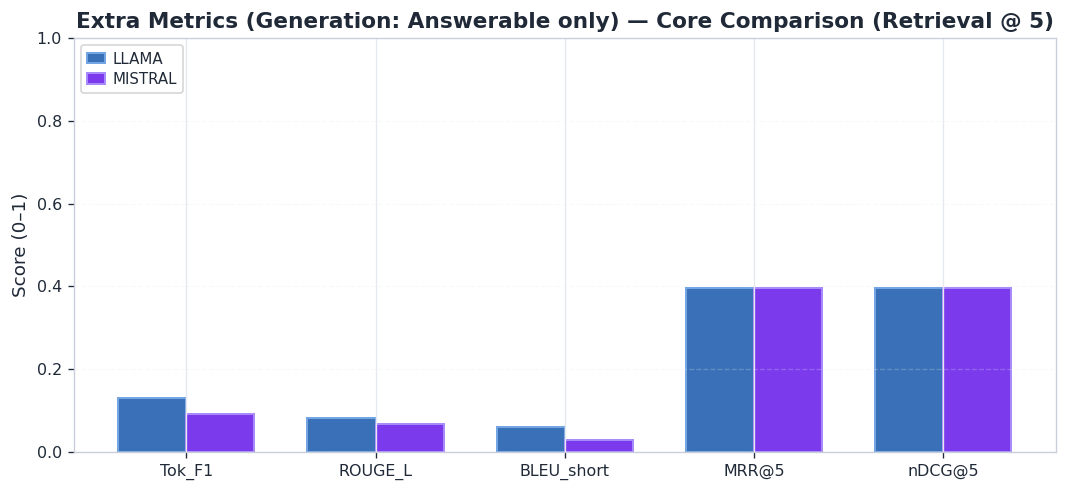

Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_core_grouped_bar.png
Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_core_grouped_bar.pdf


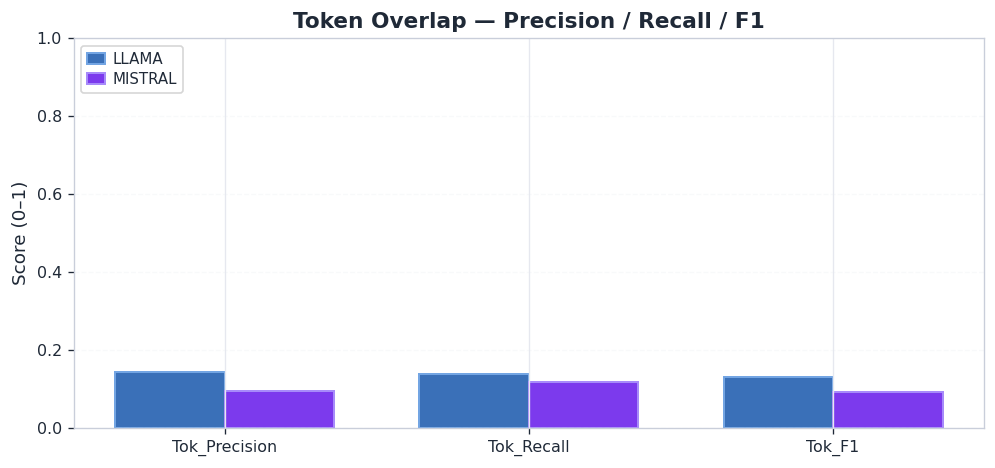

Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_token_prf_grouped_bar.png
Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_token_prf_grouped_bar.pdf


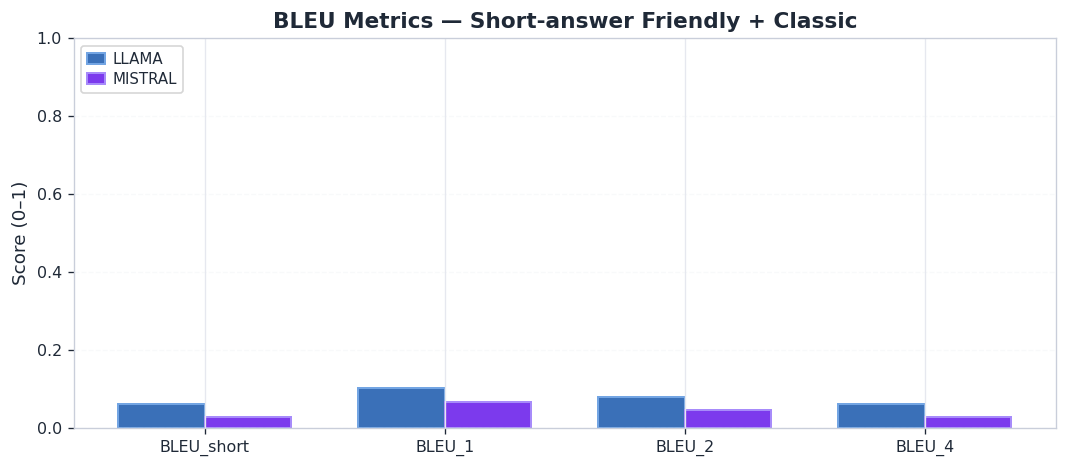

Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_bleu_grouped_bar.png
Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_bleu_grouped_bar.pdf


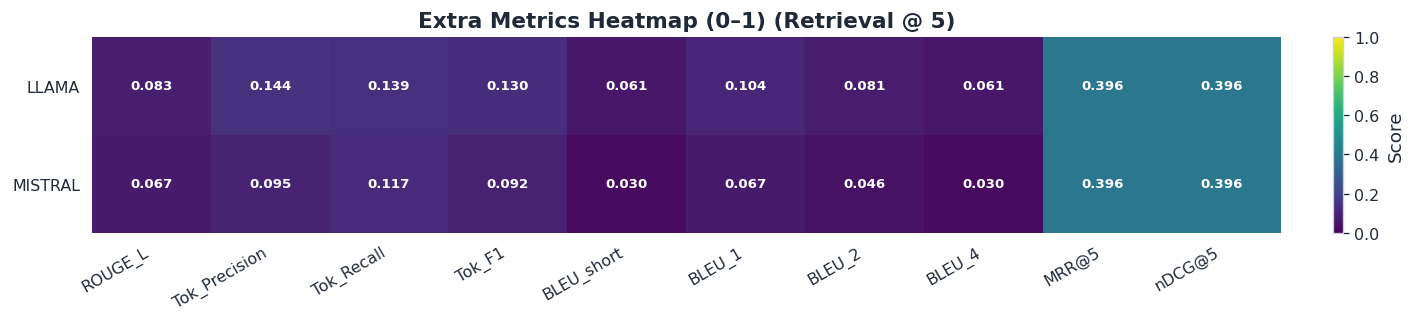

Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_metrics_heatmap.png
Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_metrics_heatmap.pdf


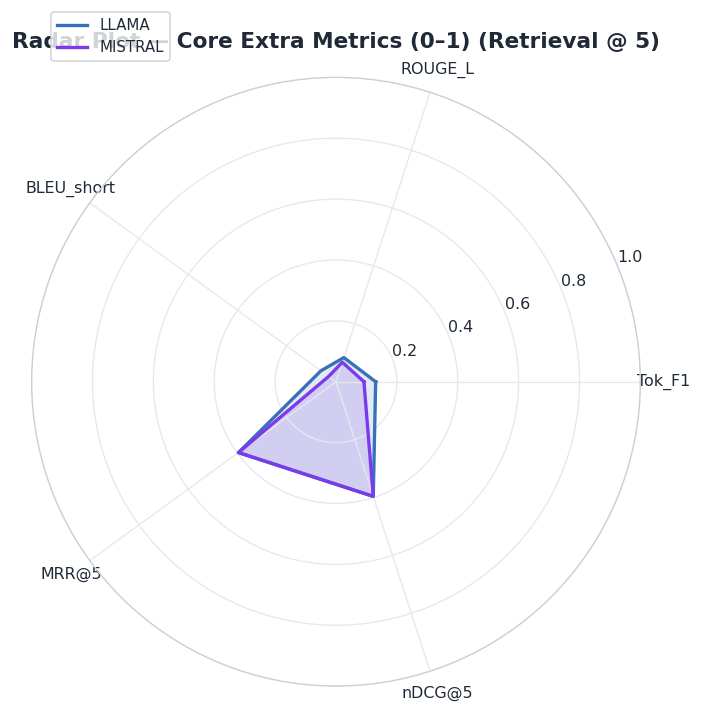

Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_core_radar.png
Saved: arabicaqa_rag_results/ragas_full\figures_extra\extra_core_radar.pdf

Done ✅ Saved CSV/JSON + all figures in: arabicaqa_rag_results/ragas_full\figures_extra


In [ ]:
# ============================================================
# FULL SCRIPT:
# Extra metrics for LLaMA + Mistral + Qwen
# - Retrieval metrics: MRR@K, nDCG@K
# - Generation metrics: ROUGE-L, BLEU, token Precision/Recall/F1
# - Saves per-question metrics
# - Saves model-level summary
# - Saves figures for 3+ models
# ============================================================

import os
import re
import ast
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = "arabicaqa_rag_results"
RAGAS_DIR = os.path.join(BASE_DIR, "ragas_full_llama_mistral_qwen")
OUTPUT_DIR = os.path.join(BASE_DIR, "extra_metrics_llama_mistral_qwen")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Prefer the context-augmented file from the new RAGAS run.
PRED_PATH = os.path.join(RAGAS_DIR, "predictions_with_retrieved_contexts.csv")

# Fallback if RAGAS has not created the augmented file yet.
if not os.path.exists(PRED_PATH):
    PRED_PATH = os.path.join(BASE_DIR, "predictions", "comparison_llama_mistral_qwen_1000.csv")

if not os.path.exists(PRED_PATH):
    raise FileNotFoundError(f"Prediction file not found: {PRED_PATH}")

TOPK = 5

CSV_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_summary.csv")
JSON_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_summary.json")
CSV_PER_QUESTION_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_per_question.csv")
JSON_PER_QUESTION_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_per_question.json")

# ============================================================
# LOAD
# ============================================================
df_results = pd.read_csv(PRED_PATH, encoding="utf-8-sig")

print("=" * 100)
print("EXTRA METRICS EVALUATION")
print("=" * 100)
print("Loaded:", PRED_PATH)
print("Shape:", df_results.shape)
print("Columns:", list(df_results.columns))

# ============================================================
# DETECT MODELS
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    c.replace(prediction_prefix, "")
    for c in df_results.columns
    if c.startswith(prediction_prefix)
]

if not model_keys:
    raise ValueError("No predicted_answer_* columns detected.")

print("\nDetected models:")
for m in model_keys:
    print(" -", m)

required_cols = ["question", "correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

df_results["is_impossible"] = df_results["is_impossible"].astype(bool)
df_results["is_answerable"] = ~df_results["is_impossible"]

# ============================================================
# UTILITIES
# ============================================================
def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x)

def safe_int(x, default=None):
    try:
        if x is None:
            return default
        if isinstance(x, float) and math.isnan(x):
            return default
        return int(float(x))
    except Exception:
        return default

def parse_maybe_list(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(v).strip() for v in parsed if str(v).strip()]
            except Exception:
                pass

        return [s]

    return [str(x).strip()] if str(x).strip() else []

def first_ref(x):
    refs = parse_maybe_list(x)
    return refs[0] if refs else ""

def normalize_arabic_text(s):
    s = safe_str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

def tokenize_arabic_simple(s):
    return normalize_arabic_text(s).split()

# ============================================================
# RETRIEVAL METRICS
# ============================================================
def mrr_at_k(gold_doc_id, retrieved_doc_ids, k):
    if gold_doc_id is None or not isinstance(retrieved_doc_ids, list):
        return 0.0

    for i, rid in enumerate(retrieved_doc_ids[:k]):
        if rid == gold_doc_id:
            return 1.0 / (i + 1)

    return 0.0

def ndcg_at_k_single_hit(gold_doc_id, retrieved_doc_ids, k):
    if gold_doc_id is None or not isinstance(retrieved_doc_ids, list):
        return 0.0

    for i, rid in enumerate(retrieved_doc_ids[:k]):
        if rid == gold_doc_id:
            return 1.0 / np.log2(i + 2)

    return 0.0

def parse_retrieved_doc_ids(x):
    """
    Handles:
    - actual list
    - stringified list
    - missing
    This assumes a retrieved_doc_ids column if available.
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [safe_int(v) for v in x if safe_int(v) is not None]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [safe_int(v) for v in parsed if safe_int(v) is not None]
            except Exception:
                return []

        # Single id string
        one = safe_int(s)
        return [one] if one is not None else []

    one = safe_int(x)
    return [one] if one is not None else []

# ============================================================
# GENERATION METRICS
# ============================================================
def token_prf_single(pred, ref):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0, 1.0, 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0, 0.0, 0.0

    pred_counts = Counter(pred_tokens)
    ref_counts = Counter(ref_tokens)

    overlap = sum((pred_counts & ref_counts).values())

    precision = overlap / len(pred_tokens) if pred_tokens else 0.0
    recall = overlap / len(ref_tokens) if ref_tokens else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return precision, recall, f1

def rouge_l_single(pred, ref):
    try:
        from rouge_score import rouge_scorer
        scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

        pred = safe_str(pred).strip()
        ref = safe_str(ref).strip()

        if pred == "" and ref == "":
            return 1.0

        if pred == "" or ref == "":
            return 0.0

        return float(scorer.score(ref, pred)["rougeL"].fmeasure)

    except Exception:
        return np.nan

def bleu_single(pred, ref):
    try:
        from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
        smoothie = SmoothingFunction().method1

        pred_tokens = tokenize_arabic_simple(pred)
        ref_tokens = tokenize_arabic_simple(ref)

        if len(pred_tokens) == 0 and len(ref_tokens) == 0:
            return 1.0, 1.0, 1.0, 1.0

        if len(pred_tokens) == 0 or len(ref_tokens) == 0:
            return 0.0, 0.0, 0.0, 0.0

        L = len(ref_tokens)

        if L <= 1:
            w_short = (1.0, 0.0, 0.0, 0.0)
        elif L == 2:
            w_short = (0.5, 0.5, 0.0, 0.0)
        elif L == 3:
            w_short = (1 / 3, 1 / 3, 1 / 3, 0.0)
        else:
            w_short = (0.25, 0.25, 0.25, 0.25)

        bleu_short = sentence_bleu(
            [ref_tokens],
            pred_tokens,
            weights=w_short,
            smoothing_function=smoothie,
        )

        bleu_1 = sentence_bleu(
            [ref_tokens],
            pred_tokens,
            weights=(1.0, 0.0, 0.0, 0.0),
            smoothing_function=smoothie,
        )

        bleu_2 = sentence_bleu(
            [ref_tokens],
            pred_tokens,
            weights=(0.5, 0.5, 0.0, 0.0),
            smoothing_function=smoothie,
        )

        bleu_4 = sentence_bleu(
            [ref_tokens],
            pred_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothie,
        )

        return float(bleu_short), float(bleu_1), float(bleu_2), float(bleu_4)

    except Exception:
        return np.nan, np.nan, np.nan, np.nan

# ============================================================
# RETRIEVAL IDS
# ============================================================
# Best case: if you saved retrieved_doc_ids during retrieval, use it.
# Otherwise, re-run retriever if available.
if "retrieved_doc_ids" in df_results.columns:
    print("\nUsing existing retrieved_doc_ids column.")
    df_results["retrieved_doc_ids_parsed"] = df_results["retrieved_doc_ids"].apply(parse_retrieved_doc_ids)

else:
    print("\nNo retrieved_doc_ids column found.")

    if "retriever" in globals():
        print("Re-retrieving document IDs using retriever.invoke(question).")

        retrieved_ids_all = []

        for q in df_results["question"].fillna("").astype(str).tolist():
            hits = retriever.invoke(q)

            ids = []
            if isinstance(hits, list):
                for d in hits[:TOPK]:
                    md = getattr(d, "metadata", None)
                    if isinstance(md, dict) and "document_id" in md:
                        rid = safe_int(md.get("document_id"), default=None)
                        if rid is not None:
                            ids.append(rid)

            retrieved_ids_all.append(ids)

        df_results["retrieved_doc_ids_parsed"] = retrieved_ids_all

    else:
        print("WARNING: retriever not found. Retrieval metrics will be NaN.")
        df_results["retrieved_doc_ids_parsed"] = [[] for _ in range(len(df_results))]

# ============================================================
# COMPUTE PER-QUESTION RETRIEVAL METRICS
# ============================================================
df_results["gold_document_id_int"] = df_results["document_id"].apply(safe_int) if "document_id" in df_results.columns else None

df_results[f"MRR@{TOPK}"] = df_results.apply(
    lambda r: mrr_at_k(
        r["gold_document_id_int"],
        r["retrieved_doc_ids_parsed"],
        TOPK
    ),
    axis=1
)

df_results[f"nDCG@{TOPK}"] = df_results.apply(
    lambda r: ndcg_at_k_single_hit(
        r["gold_document_id_int"],
        r["retrieved_doc_ids_parsed"],
        TOPK
    ),
    axis=1
)

retrieval_mrr_mean = float(df_results[f"MRR@{TOPK}"].mean())
retrieval_ndcg_mean = float(df_results[f"nDCG@{TOPK}"].mean())

print(f"\n[Retrieval] MRR@{TOPK}: {retrieval_mrr_mean:.6f}")
print(f"[Retrieval] nDCG@{TOPK}: {retrieval_ndcg_mean:.6f}")

# ============================================================
# COMPUTE PER-QUESTION GENERATION METRICS
# Answerable only gets metrics; unanswerable becomes NaN.
# ============================================================
per_question_rows = []

for _, row in df_results.iterrows():
    base = {
        "row_idx": row.get("row_idx", row.name),
        "question_id": row.get("question_id", ""),
        "document_id": row.get("document_id", ""),
        "question": row.get("question", ""),
        "is_impossible": bool(row.get("is_impossible", False)),
        "is_answerable": bool(row.get("is_answerable", not bool(row.get("is_impossible", False)))),
        f"MRR@{TOPK}": row.get(f"MRR@{TOPK}", np.nan),
        f"nDCG@{TOPK}": row.get(f"nDCG@{TOPK}", np.nan),
    }

    ref = first_ref(row.get("correct_answers", ""))

    for model_key in model_keys:
        pred_col = f"predicted_answer_{model_key}"
        gen_latency_col = f"latency_sec_{model_key}"

        pred = row.get(pred_col, "")

        out = base.copy()
        out["model"] = model_key
        out["prediction"] = pred
        out["reference"] = ref

        if gen_latency_col in df_results.columns:
            out["generation_latency_sec"] = row.get(gen_latency_col, np.nan)
        else:
            out["generation_latency_sec"] = np.nan

        if bool(row.get("is_answerable", False)):
            tok_p, tok_r, tok_f1 = token_prf_single(pred, ref)
            rouge_l = rouge_l_single(pred, ref)
            bleu_short, bleu_1, bleu_2, bleu_4 = bleu_single(pred, ref)
        else:
            tok_p, tok_r, tok_f1 = np.nan, np.nan, np.nan
            rouge_l = np.nan
            bleu_short, bleu_1, bleu_2, bleu_4 = np.nan, np.nan, np.nan, np.nan

        out["Tok_Precision"] = tok_p
        out["Tok_Recall"] = tok_r
        out["Tok_F1"] = tok_f1
        out["ROUGE_L"] = rouge_l
        out["BLEU_short"] = bleu_short
        out["BLEU_1"] = bleu_1
        out["BLEU_2"] = bleu_2
        out["BLEU_4"] = bleu_4

        per_question_rows.append(out)

df_extra_pq = pd.DataFrame(per_question_rows)

# ============================================================
# SUMMARY
# ============================================================
generation_metric_cols = [
    "ROUGE_L",
    "Tok_Precision",
    "Tok_Recall",
    "Tok_F1",
    "BLEU_short",
    "BLEU_1",
    "BLEU_2",
    "BLEU_4",
]

summary_rows = []

for model_key in model_keys:
    df_m = df_extra_pq[df_extra_pq["model"] == model_key].copy()
    df_m_ans = df_m[df_m["is_answerable"] == True].copy()

    row = {
        "model": model_key,
        "n_questions_all": int(len(df_m)),
        "n_questions_answerable": int(len(df_m_ans)),
        f"MRR@{TOPK}": float(df_m[f"MRR@{TOPK}"].mean(skipna=True)),
        f"nDCG@{TOPK}": float(df_m[f"nDCG@{TOPK}"].mean(skipna=True)),
        "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
        "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
        "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
    }

    for m in generation_metric_cols:
        row[m] = float(df_m_ans[m].mean(skipna=True))

    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

# ============================================================
# SAVE
# ============================================================
df_extra_pq.to_csv(CSV_PER_QUESTION_PATH, index=False, encoding="utf-8-sig")
df_extra_pq.to_json(JSON_PER_QUESTION_PATH, orient="records", force_ascii=False, indent=2)

df_summary.to_csv(CSV_SUMMARY_PATH, index=False, encoding="utf-8-sig")
df_summary.to_json(JSON_SUMMARY_PATH, orient="records", force_ascii=False, indent=2)

print("\nSaved:")
print("Per-question CSV:", CSV_PER_QUESTION_PATH)
print("Per-question JSON:", JSON_PER_QUESTION_PATH)
print("Summary CSV:", CSV_SUMMARY_PATH)
print("Summary JSON:", JSON_SUMMARY_PATH)

print("\nExtra metrics summary:")
print(df_summary.round(4).to_string(index=False))

# ============================================================
# PLOTTING
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

MODEL_COLORS = {
    "llama": "#3A70B8",
    "mistral": "#7C3AED",
    "qwen": "#0F9D58",
}
DEFAULT_COLOR = "#777777"

def save_and_show(fig, name):
    png = os.path.join(FIG_DIR, f"{name}.png")
    pdf = os.path.join(FIG_DIR, f"{name}.pdf")

    fig.tight_layout()
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", png)
    print("Saved:", pdf)

def grouped_bar(df, metrics, title, ylabel, filename):
    models = df["model"].astype(str).tolist()
    x = np.arange(len(metrics))
    width = 0.8 / max(len(models), 1)

    fig, ax = plt.subplots(figsize=(max(9, len(metrics) * 1.2), 4.5))

    for i, model in enumerate(models):
        values = df[df["model"].astype(str) == model][metrics].iloc[0].astype(float).values
        offset = (i - (len(models) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width,
            label=model,
            color=MODEL_COLORS.get(model.lower(), DEFAULT_COLOR),
            edgecolor="black",
            linewidth=0.7
        )

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.0)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    save_and_show(fig, filename)

# Core metrics
core_metrics = [
    "Tok_F1",
    "ROUGE_L",
    "BLEU_short",
    f"MRR@{TOPK}",
    f"nDCG@{TOPK}",
]
core_metrics = [m for m in core_metrics if m in df_summary.columns]

grouped_bar(
    df_summary,
    core_metrics,
    f"Extra Metrics Summary (Retrieval @ {TOPK}; Generation on Answerable Questions)",
    "Score",
    "extra_core_grouped_bar"
)

# Token PRF
prf_metrics = ["Tok_Precision", "Tok_Recall", "Tok_F1"]
prf_metrics = [m for m in prf_metrics if m in df_summary.columns]

grouped_bar(
    df_summary,
    prf_metrics,
    "Token Overlap Metrics on Answerable Questions",
    "Score",
    "extra_token_prf_grouped_bar"
)

# BLEU family
bleu_metrics = ["BLEU_short", "BLEU_1", "BLEU_2", "BLEU_4"]
bleu_metrics = [m for m in bleu_metrics if m in df_summary.columns]

grouped_bar(
    df_summary,
    bleu_metrics,
    "BLEU Metrics on Answerable Questions",
    "Score",
    "extra_bleu_grouped_bar"
)

# Heatmap
heat_metrics = [
    "ROUGE_L",
    "Tok_Precision",
    "Tok_Recall",
    "Tok_F1",
    "BLEU_short",
    "BLEU_1",
    "BLEU_2",
    "BLEU_4",
    f"MRR@{TOPK}",
    f"nDCG@{TOPK}",
]
heat_metrics = [m for m in heat_metrics if m in df_summary.columns]

if heat_metrics:
    mat = df_summary.set_index("model")[heat_metrics].astype(float)
    fig, ax = plt.subplots(figsize=(12.5, max(3.0, 0.6 * len(mat))))

    im = ax.imshow(mat.values, aspect="auto", vmin=0, vmax=1)

    ax.set_title("Extra Metrics Heatmap")
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_yticklabels(mat.index.tolist())

    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_xticklabels(mat.columns.tolist(), rotation=30, ha="right")

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            color = "white" if val < 0.5 else "black"
            ax.text(
                j,
                i,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=color,
                fontweight="bold"
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Score")

    save_and_show(fig, "extra_metrics_heatmap")

# Latency figure
latency_metrics = [
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
]
latency_metrics = [m for m in latency_metrics if m in df_summary.columns]

if latency_metrics:
    models = df_summary["model"].astype(str).tolist()
    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.bar(
        x - width,
        df_summary["generation_latency_mean_sec"],
        width,
        label="Mean",
        edgecolor="black",
        linewidth=0.7
    )
    ax.bar(
        x,
        df_summary["generation_latency_median_sec"],
        width,
        label="Median",
        edgecolor="black",
        linewidth=0.7
    )
    ax.bar(
        x + width,
        df_summary["generation_latency_p95_sec"],
        width,
        label="P95",
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_title("Generation Latency per Query")
    ax.set_ylabel("Seconds / Query")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    save_and_show(fig, "extra_generation_latency")

print("\nDone. Extra metrics and figures saved in:", OUTPUT_DIR)